<h1><center>Laboratorio 10: Adivina, Adivinador 🔮</center></h1>

<center><strong>MDS7202: Laboratorio de Programación Científica para Ciencia de Datos - Otoño 2025</strong></center>

### Cuerpo Docente:

- Profesores: Stefano Schiappacasse, Sebastián Tinoco
- Auxiliares: Melanie Peña, Valentina Rojas
- Ayudantes: Angelo Muñoz, Valentina Zúñiga

### **Equipo: SUPER IMPORTANTE - notebooks sin nombre no serán revisados**

- Nombre de alumno 1: Francisco Maldonado
- Nombre de alumno 2:

### **Link de repositorio de GitHub:** [Insertar Repositorio](https://github.com/FranMP999/)

## Temas a tratar
- Series de Tiempo.
- Predicciones vía `Prophet`.
- Implementar un sistema de recomendación utilizando `surprise`.

## Reglas:

- **Grupos de 2 personas**
- Fecha de entrega: 6 días de plazo con descuento de 1 punto por día. Entregas Martes a las 23:59.
- Instrucciones del lab el viernes a las 16:15 en formato online. Asistencia no es obligatoria, pero se recomienda fuertemente asistir.
- <u>Prohibidas las copias</u>. Cualquier intento de copia será debidamente penalizado con el reglamento de la escuela.
- Tienen que subir el laboratorio a u-cursos y a su repositorio de github. Labs que no estén en u-cursos no serán revisados. Recuerden que el repositorio también tiene nota.
- Cualquier duda fuera del horario de clases al foro. Mensajes al equipo docente serán respondidos por este medio.
- Pueden usar cualquier material del curso que estimen conveniente.

### Objetivos principales del laboratorio
- Comprender qué es una serie de tiempo y su estructura.
- Identificar tendencias, estacionalidades e irregularidades.
- Armar un modelo predictivo para la serie.
- Conocer y aplicar sistemas de recomendación.
- Entender estructura y conocer casos de estudio.


In [ ]:
# Si usted está utilizando Colabolatory le puede ser útil este código para cargar los archivos.
try:
    from google.colab import drive
    drive.mount("/content/drive")
    path = 'Dirección donde tiene los archivos en el Drive'
except:
    print('Ignorando conexión drive-colab')

In [4]:
# Librerias globales

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import copy
import plotly.express as px
from statsmodels.tsa.stattools import adfuller


from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.metrics import mean_absolute_error
sns.set()

# **1. Forecasting (30 puntos)**


## **Prophet**

Prophet es una herramienta open-source de Facebook utilizada para realizar predicciones en series de tiempo. Esta se basa en la descomposición aditiva, donde tendencias no lineales se ajustan junto a la estacionalidad.

En la ecuación de a continuación se puede ver una idea general de los elementos que construyen a un modelo aditivo como lo es Prophet.

\begin{equation}
y(t) = g(t) + s(t) + h(t) + e(t)
\end{equation}

Donde, $g(t)$ hace referencia a las tendencias, que corresponden a cambios graduales en largos periodos de tiempo. $s(t)$ corresponde a la estacionalidad, son cambios periodicos o cortos en el tiempo. $h(t)$ es el efecto que tienen las festividades sobre las predicciones, mientras que e(t) corresponde al error o ruido. Finalmente $y(t)$, es la predicción hecha por el modelo.

Prophet trabaja por defecto con Piece-Wise Lineal Model, este es un modelo de regresión lineal, en el cual se buscan distintas zonas en que la data presente patrones o tendencias lineales, de estas zonas obtiene su regresión y luego las "une" de manera de representar toda la región, como se puede ver en la ecuación siguiente.

\begin{equation}
y(x)=
    \begin{cases}
        η_1 + \beta_1(x-b_1), & b_1 < x  \leqslant b_2 \\
        η_2 + \beta_2(x-b_2), & b_2 < x  \leqslant b_3 \\
        η_3 + \beta_3(x-b_3), & b_3 < x  \leqslant b_3 \\
        ... \\
        η_k + \beta_{nb}(x-b_{nb-1}), & b_{n-1} < x  \leqslant b_{nb} \\
    \end{cases}
\end{equation}

Siendo $b_1$ el primer punto de quiebre en la serie y así hasta el punto $b_{nb}$ correspondiente al último punto de quiebre de la serie con una cantidad $nb$ de puntos.

Para mayor información de Prophet y como utilizarla, pueden ver su [documentación](https://facebook.github.io/prophet/docs/quick_start.html#python-api), donde hay pueden encontrar un pequeño tutorial de la librería.

## **La Factura de Homero**

<center>
<img src ="https://i.makeagif.com/media/7-30-2018/H_ZAY1.gif" width = 500 />

Homero Simpson ha trabajado en la Planta Nuclear de Springfield por más de 20 años como Inspector de Seguridad, pero recientemente el Sr. Burns le ha permitido trabajar desde casa. Aunque le encanta la flexibilidad que esto le otorga, también ha notado un aumento considerable en su consumo energético en el hogar. Con el uso constante de calefacción en invierno y aire acondicionado en verano, Homero está preocupado por cómo afectará esto a su presupuesto en los próximos meses, ya que planea pasar aún más tiempo en casa.

Afortunadamente, gracias a su puesto en la Planta de Energía Nuclear, Homero tiene acceso a los datos de consumo de energía de cada ciudadano en Springfield, por lo que accede a esta información y almacena el consumo de su hogar en un archivo llamado `energia_homero.csv`. Este archivo posee el consumo diario en el hogar de Homero Simpson desde el Junio del 2016 hasta Julio del 2020.

Con esta valiosa información, Homero espera poder predecir su consumo energético y tomar decisiones informadas para ajustar su presupuesto mensual.

Los datos son los siguientes:

* **date**: Fecha de medición.
* **Energy_kWh**: Consumo diario de energía eléctrica en el hogar de Homero (en kWh).

## 1.1 Series de Tiempo [0 puntos]

### Carga de los datos

En primer lugar, cargue los datos históricos del archivo `energia_homero.csv` al entorno de trabajo. Una vez cargados, asegúrense de transformar la columna `date` a formato `datetime`. Además, visualice el consumo de energía en la casa de Homero mediante la librería `plotly`.


**Respuesta**:

,date,Energy_kWh
0,2016-06-01,29.691
1,2016-06-02,28.789
2,2016-06-03,19.247
3,2016-06-04,22.883
4,2016-06-05,25.195
...,...,...
1493,2020-07-03,39.659
1494,2020-07-04,38.071
1495,2020-07-05,36.565
1496,2020-07-06,39.900


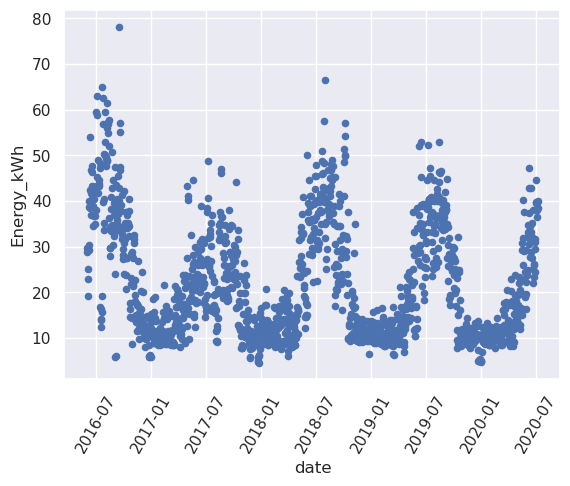

In [23]:

#Codigo Aqui
df = (
    pd.read_csv("energia_homero.csv")
    .assign( date=lambda x: pd.to_datetime(x.date))
        )
display(df)

target = 'Energy_kWh'
df.plot(x="date", y=target, kind="scatter")
plt.xticks(rotation=60)
plt.show()

## 1.2 Controlando la Serie de Tiempo [6 puntos]

<center>
<img src ="https://i.pinimg.com/originals/66/77/88/667788e0b1f08ff1e1cfce11d303b203.gif" width = 500 />

Luego de leer mucho, Homero cree que necesita descomponer la serie de tiempo para poder controlar estos componentes de forma efectiva y lograr que la serie tenga propiedades de una serie estacionaria.

Usted, como buen ciudadano de Springfield, decide ayudar a Homero, el cual le pide que realice lo siguientes pasos:

0. Cree un conjunto de entrenamiento y uno de prueba (a proyectar). Para ello, considere como entrenamiento la información **hasta** el `2020-02-29` y como conjunto de prueba **desde** el `2020-03-01`. [0 puntos]
1. Cree un `Pipeline` que permita obtener una representación de la tendencia de la serie de tiempo, mediante un modelo Lineal. Nombre al pipeline `Pipeline_trend`. [1 punto]
2. Entrene el modelo lineal y luego obtenga predicciones tanto para el conjunto de entrenamiento como para el de prueba (intervalo completo de tiempo). Luego grafique las predicciones y calcule el `Mean Absolute Error` (MAE), tanto para el conjunto de prueba como para el de entrenamiento. [1 punto]
3. Grafique el error (Valor real - Valor predicho) para todo el intervalo de tiempo y responda ¿Hay un comportamiento estacional en la serie? [1 punto]
4.  Cree un `Pipeline` que permita modelar la estacionalidad de la serie temporal mediante términos de Fourier y la represente a través de una Regresión Lineal de la variable objetivo. Nombre a este pipeline `Pipeline_seasonal`. Determine el valor de Periodos `P` y el número de terminos de Fourier `n`. [1 punto]
5. Entrene el nuevo modelo y obtenga predicciones en el intervalo completo de tiempo. Luego grafique y calcule el `MAE` en el conjunto de prueba y en el de entrenamiento. [1 punto]
6. Vuelva a graficar el error y comente los resultados. [1 punto]

**Respuesta**

% destinado a train: 0.91
% destinado a test: 0.09


,date,Energy_kWh
0,2016-06-01,29.691
1,2016-06-02,28.789
2,2016-06-03,19.247
3,2016-06-04,22.883
4,2016-06-05,25.195
...,...,...
1364,2020-02-25,9.630
1365,2020-02-26,10.203
1366,2020-02-27,12.040
1367,2020-02-28,10.771


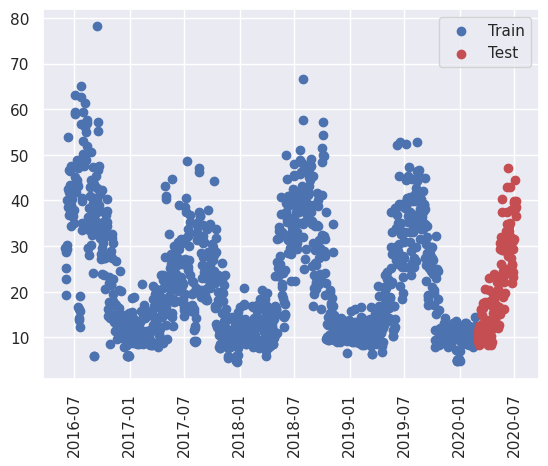

In [16]:
#CODIGO AQUI
df['set'] = np.where(df.date > pd.Timestamp('2020-02-29'), 'Test', 'Train')

train = df[df['set'] == 'Train'].copy()
test = df[df['set'] == 'Test'].copy()


X_train = train.drop(columns = ['set'])
y_train = train.set_index("date")[target].copy()

X_test = test.drop(columns = ['set'])
y_test = test.set_index("date")[target].copy()

print(f'% destinado a train: {len(train) / len(df):.2f}')
print(f'% destinado a test: {len(test) / len(df):.2f}')

display(X_train)

plt.scatter(df.date[df.set=="Train"], df[target][df.set=="Train"], c="b", label="Train")
plt.scatter(df.date[df.set=="Test"], df[target][df.set=="Test"], c="r", label="Test")
plt.legend()
plt.xticks(rotation=90)
plt.show()

In [24]:
class Resultados:
    def __init__(
            self,
            train_pred: pd.core.series.Series,
            test_pred: pd.core.series.Series,
            y_train: pd.core.series.Series=y_train,
            y_test: pd.core.series.Series=y_test,
            date_label: str="ds"
    ):
        assert (
            (train_pred.index == y_train.index).all()
            and
            (test_pred.index == y_test.index).all()
            ), "índices de series deben calzar"
        self.train_pred = train_pred
        self.test_pred = test_pred
        self.y_train = y_train
        self.y_test = y_test
        self.mae_train = mean_absolute_error(
            y_train,
            train_pred,
        )
        self.mae_test = mean_absolute_error(
            y_test,
            test_pred,
        )

    def print_maes(self):
        print(f'MAE Train: {self.mae_train:.2f}')
        print(f'MAE Test: {self.mae_test:.2f}')

    def plot_prediction(self, title="Predicción", prediction_label="Predicción"):
        y_pred = pd.concat([self.train_pred, self.test_pred])
        y_real = pd.concat([self.y_train, self.y_test])
        plt.scatter(y_real.index, y_real, c="b", label="Real")
        plt.plot(y_pred.index, y_pred, c="orange", label=prediction_label)
        plt.title(title)
        plt.xticks(rotation=60)
        plt.legend()
        plt.show()

    def plot_error(self, title="Error en la predicción"):
        error_train = self.y_train - self.train_pred
        error_test = self.y_test - self.test_pred
        error = pd.concat([error_train, error_test])

        plt.plot(error_train.index, error_train, c="b", label="Train")
        plt.plot(error_test.index, error_test, c="orange", label="Test")

        plt.legend()
        plt.xticks(rotation=60)
        plt.title(title)
        plt.show()
        
    def test_estacionaridad(self):
        error_train = self.y_train - self.train_pred
        error_test = self.y_test - self.test_pred
        error = pd.concat([error_train, error_test])
        
        result = adfuller(error)
        print('ADF Statistic:', result[0])
        print('p-value:', result[1])


### Trend

MAE Train: 10.57
MAE Test: 8.66


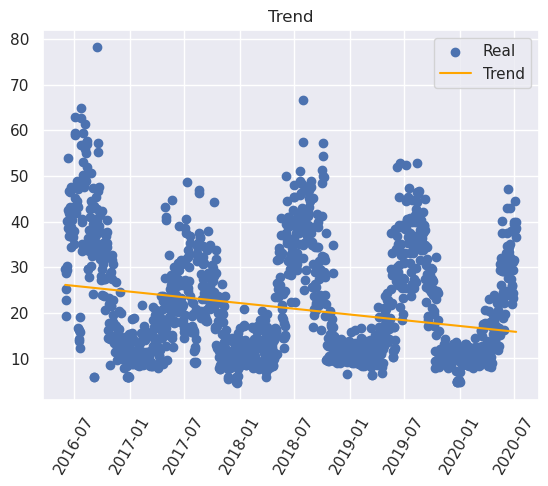

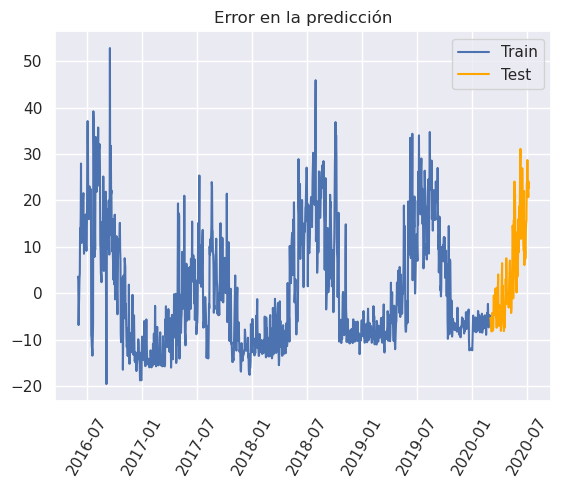

ADF Statistic: -2.7379852210733366
p-value: 0.0676926397702059


In [25]:
class TimeTransformer(TransformerMixin, BaseEstimator):
    def __init__(self):

        self.init_date = None

    def fit(self, X, y=None):

        assert isinstance(X, pd.DataFrame), 'df must be a pandas DataFrame'
        assert 'date' in X.columns, 'date must be a column of DataFrame'

        self.init_date = X.date.iloc[0]

        return self

    def transform(self, X):

        X = X.copy()

        assert self.init_date is not None, 'transformer must be fitted first!'
        assert isinstance(X, pd.DataFrame), 'df must be a pandas DataFrame'
        assert 'date' in X.columns, 'date must be a column of DataFrame'

        final_date = X.date.iloc[-1] # last date of X

        # generate trend series
        count = (final_date - self.init_date).days + 1
        X['trend'] = [i for i in range(count)][-len(X):]

        return X[['trend']]

    def fit_transform(self, X, y=None):

        X = X.copy()

        assert isinstance(X, pd.DataFrame), 'df must be a pandas Dataframe'
        assert 'date' in X.columns, 'date must be a column of DataFrame'

        self.trend = len(X)
        self.init_date = X.date.iloc[0]

        final_date = X.date.iloc[-1] # last date of X

        # generate trend series
        count = (final_date - self.init_date).days + 1
        X['trend'] = [i for i in range(count)][-len(X):]

        return X[['trend']]

pipeline = Pipeline([
    ('time_features', TimeTransformer()),
    ('ols', LinearRegression())
])


pipeline.fit(X_train, y_train)
train_pred = pd.Series(pipeline.predict(X_train), index=X_train.date)
test_pred = pd.Series(pipeline.predict(X_test), index=X_test.date)

resultados_trend = Resultados(
    train_pred = pd.Series(pipeline.predict(X_train), index=X_train.date),
    test_pred = pd.Series(pipeline.predict(X_test), index=X_test.date)
 )
resultados_trend.print_maes()
resultados_trend.plot_prediction(title="Trend", prediction_label="Trend")
resultados_trend.plot_error()
resultados_trend.test_estacionaridad()

En los gráficos se puede observar con claridad que existe un componente estacional en la serie. Lo cual queda confirmado por el valor de p-value asociado al test ADF, superior a 0.05.

### Estacionalidad

MAE Train: 5.35
MAE Test: 4.46


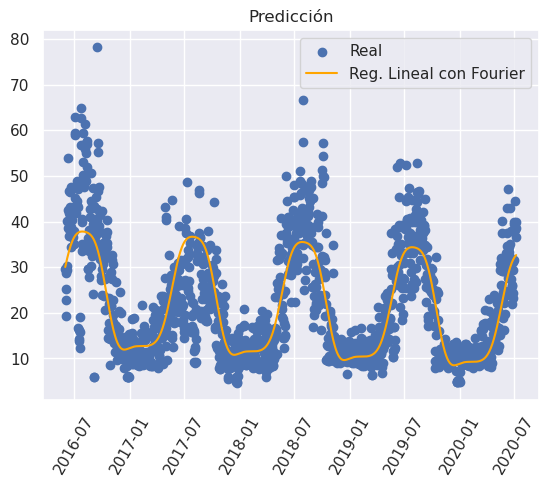

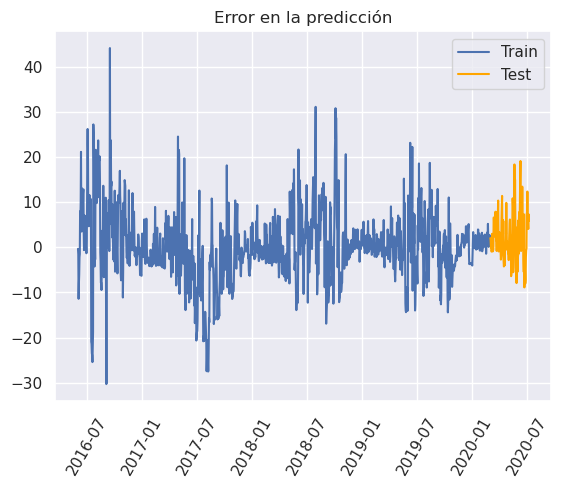

ADF Statistic: -9.72376742557329
p-value: 9.392263102823466e-17


In [26]:
class TimeTransformer_Fourier(TransformerMixin, BaseEstimator):
    def __init__(self, n = 4, p = 365):

        self.init_date = None
        self.n = n
        self.p = p

    def fit(self, X, y=None):

        '''
        Realiza el fit sobre los datos --> guarda la fecha de inicio de entrenamiento.
        '''

        assert isinstance(X, pd.DataFrame), 'df must be a pandas DataFrame'
        assert 'date' in X.columns, 'date must be a column of DataFrame'

        self.init_date = X.date.iloc[0]

    def transform(self, X):

        '''
        Realiza el transform sobre el conjunto X, retornando los términos de fourier.
        '''

        X = X[['date']].copy()

        assert self.init_date is not None, 'transformer must be fitted first!'
        assert isinstance(X, pd.DataFrame), 'df must be a pandas Dataframe'
        assert 'date' in X.columns, 'date must be a column of DataFrame'

        final_date = X.index[-1] # last date of X
        final_date = X.date.iloc[-1] # last date of X

        # generate trend series
        count = (final_date - self.init_date).days + 1
        X['trend'] = [i for i in range(count)][-len(X):]

        # generate fourier terms
        fourier = self.get_fourier_terms(X['trend'], self.n, self.p)

        # concatenate trend + fourier
        X = pd.concat([X, fourier], axis = 1).drop(columns = 'date')

        return X

    def fit_transform(self, X, y=None):

        '''
        implementa el método fit y transform a la vez.
        '''

        X = X[['date']].copy()

        assert isinstance(X, pd.DataFrame), 'df must be a pandas Dataframe'
        assert 'date' in X.columns, 'date must be a column of DataFrame'

        self.trend = len(X)
        self.init_date = X.date.iloc[0]

        final_date = X.date.iloc[-1] # last date of X

        # generate trend series
        count = (final_date - self.init_date).days + 1
        X['trend'] = [i for i in range(count)][-len(X):]

        # generate fourier terms
        fourier = self.get_fourier_terms(X['trend'], self.n, self.p)

        # concatenate trend + fourier
        X = pd.concat([X, fourier], axis = 1).drop(columns = 'date')

        return X

    def get_fourier_terms(self, serie, n, p):

        '''
        Obtiene los términos de fourier de una serie
        '''

        terms = []
        for i in range(1, n + 1):
            sine_term = np.sin(2 * np.pi * i * serie / p)
            cosine_term = np.cos(2 * np.pi * i * serie / p)
            terms.extend([sine_term, cosine_term])

        fourier = np.column_stack(terms)
        fourier = pd.DataFrame(fourier, columns = [f'fourier_{i}' for i in range(n * 2)], index = serie.index) # este paso es opcional

        return fourier

# definir Pipeline
pipeline_fourier = Pipeline([
    ('time_features', TimeTransformer_Fourier(n = 4, p = 365)),
    ('ols', LinearRegression())
])

# entrenar y predecir
pipeline_fourier.fit(X_train, y_train)
resultados_trend = Resultados(
    train_pred = pd.Series(pipeline_fourier.predict(X_train), index=X_train.date),
    test_pred = pd.Series(pipeline_fourier.predict(X_test), index=X_test.date)
 )

resultados_trend.print_maes()
resultados_trend.plot_prediction(title="Predicción", prediction_label="Reg. Lineal con Fourier")
resultados_trend.plot_error()
resultados_trend.test_estacionaridad()

Gracias a los términos de fourier se logra capturar en gran medida el comportamiento estacional de la serie, ahora sí pasando el test ADF. Sin embargo el gráfico del error no parece ruido blanco, sino que se capturan comportamientos cíclicos, con 5 zonas de pronunciada desviación estándar. Además se logra una reducción sustancial del MAE en el conjunto de prueba con respecto a la sóla regresión lineal.

## 1.3 Un Consejo para Homero [6 puntos]

<center>
<img src ="https://media.tenor.com/sjbvGMLZiDkAAAAM/the-simpsons-homner-simpson.gif" width = 400 />

Homero al observar los resultados obtenidos, se mostró conforme y decidió no seguir averiguando al respecto. Usted, como buen amigo y utilizando sus recientes conocimientos en Forecast, le sugiere a Homero utilizar **Prophet**, una herramienta de modelado de series de tiempo que incluye descomposición de tendencias y estacionalidad, así como la capacidad de incorporar regresores adicionales. Usted le explica a Homero que Prophet es especialmente útil para realizar pronósticos cuando hay patrones estacionales y que podría mejorar los resultados que ha obtenido hasta ahora.

Homero, algo agotado debido al exhaustivo estudio que hizo para entender como funciona esta herramienta, le solicita ayuda para implementar Prophet y evaluar si puede obtener mejores resultados en sus predicciones de consumo energético.

Dado esto, Homero le pide que realice los siguientes pasos:

1. Instale y cargue Prophet a su entorno de trabajo. Luego renombre la variable temporal `date` por `ds` y la variable objetivo `Energy_kWh` por `y`, en los conjuntos de entrenamiento y de prueba. [1 punto]
2. Cree y ajuste el modelo Prophet con sus datos de entrenamiento. Luego realice prepare el dataset de predicciones con su set de prueba y realice las predicciones. `Nota:` Le puede ser útil este [Enlace](https://facebook.github.io/prophet/docs/quick_start.html#python-api) [2 puntos]
3. Grafique las predicciones y las componentes del modelo Prophet. `Nota`: Utilice los métodos `.plot()` y `.plot_components()` de Prophet. [1 punto]
4. Calcule el `MAE` de la predicción en el conjunto de entrenamiento y de prueba. [1 punto]
5. Grafique el error (Valor real - Valor predicho) en todo el intervalo de tiempo. Analice sus resultados y responda: ¿Hay un comportamiento estacional en la serie? [1 punto]

In [27]:
# librerias extras
from prophet import Prophet
from prophet.plot import plot_plotly, plot_components_plotly

def prophet_displays(model, forecast):
    display(forecast[['ds', 'yhat', 'yhat_lower', 'yhat_upper']].tail(10))
    m.plot(forecast )
    plt.show()
    m.plot_components(forecast )
    plt.show()

**Respuesta:**

In [28]:

#CODIGO AQUI
X_train.rename(columns={
    "date": "ds",
    target: 'y',
}, inplace=True)

X_test.rename(columns={
    "date": "ds",
    target: 'y',
}, inplace=True)

m = Prophet()
m.fit(X_train)

22:15:22 - cmdstanpy - INFO - Chain [1] start processing
22:15:22 - cmdstanpy - INFO - Chain [1] done processing


,ds,yhat,yhat_lower,yhat_upper
1488,2020-06-28,31.979684,22.676656,41.991880
1489,2020-06-29,29.998199,21.419386,38.770952
1490,2020-06-30,29.580814,21.019887,39.198392
1491,2020-07-01,29.906760,21.149124,39.192728
1492,2020-07-02,30.079803,21.527147,38.619501
1493,2020-07-03,29.916835,20.417451,38.818845
1494,2020-07-04,31.746043,23.637053,40.415441
1495,2020-07-05,32.443075,23.403486,40.694649
1496,2020-07-06,30.518109,21.480925,39.533250
1497,2020-07-07,30.145725,21.510892,39.240951


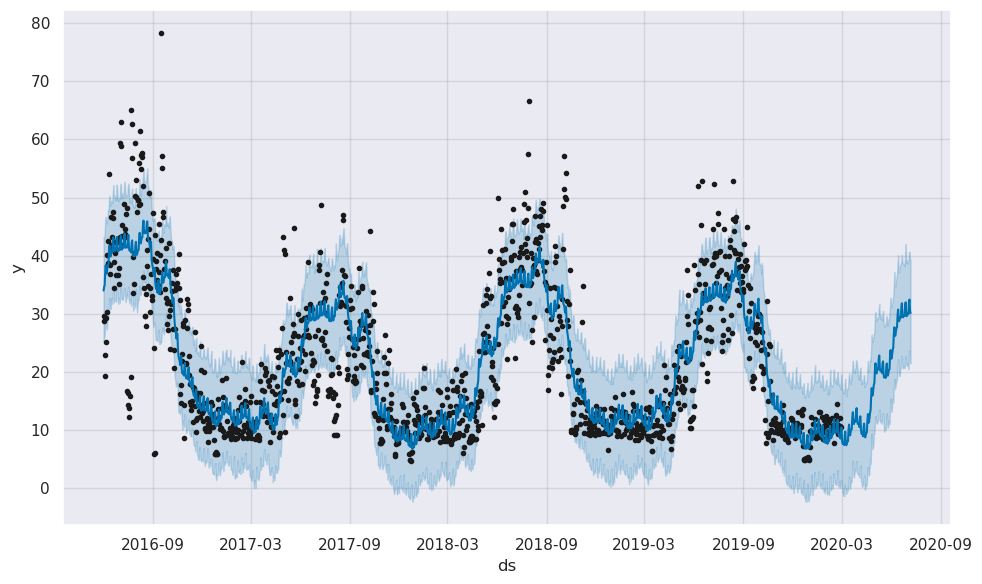

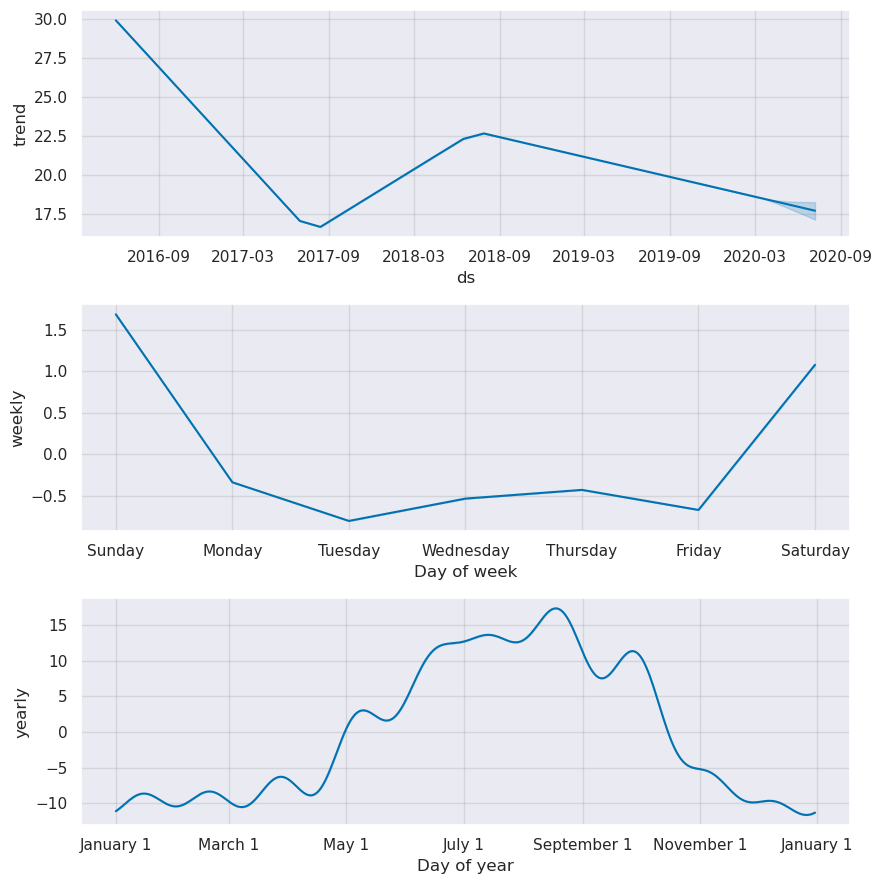

MAE Train: 4.82
MAE Test: 4.92


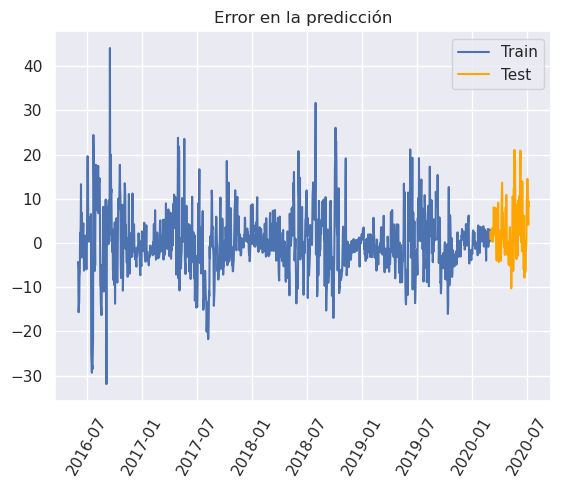

ADF Statistic: -9.72376742557329
p-value: 9.392263102823466e-17


In [30]:
forecast = m.predict(
    pd.concat([
        X_train,
        X_test,
            ]).ds.to_frame()
)
prophet_displays(m, forecast)

resultados_prophet = Resultados(
    train_pred = forecast.set_index('ds').loc[X_train.ds].yhat,
    test_pred = forecast.set_index('ds').loc[X_test.ds].yhat
 )

resultados_prophet.print_maes()
resultados_prophet.plot_error()
resultados_trend.test_estacionaridad()

Gracias a los términos de fourier se logra capturar en gran medida el comportamiento estacional de la serie, ahora sí pasando el test ADF. Sin embargo el gráfico del error no parece ruido blanco, sino que se capturan comportamientos cíclicos, con 5 zonas de pronunciada desviación estándar, similar al caso anterior. Mientras que el MAE en test es superior al previamente obtenido.

## 1.4 Incluyendo Regresores [5 puntos]

<center>
<img src ="https://i.redd.it/64hwjftunjjd1.gif" width = 400 />

Con los nuevos resultados obtenidos del modelo Prophet, usted le aconseja a Homero que puede mejorar sus predicciones al incluir regresores en el modelo, es decir, variables adicionales que pueden influir en la variable objetivo, en este caso, el consumo energético. Homero encuentra que es una buena idea y va en busca de ayuda donde el Profesor Frink, un destacado Científico de Springfield. Para suerte de Homero, Frink tenía un estudio reciente que registra las condiciones climáticas en Springfield, en el mismo intervalo de tiempo en que Homero disponía de los datos de consumo eléctrico. Con esta nueva información, usted le recomienda a Homero que podrían utilizar esta información meteorológica proporcionada como variables exógenas al modelo.

Sin embargo, al no comprender bien la importancia de los regresores, Homero decide confiar en sus capacidades y le pide que, por favor, incluya estas variables en el modelo para evaluar su impacto en las predicciones.

Para ello, usted debe:
0. Seleccionar las variables exógenas a utilizar del archivo `datos_frink.csv`. Añada estas variables a sus conjuntos de entrenamiento y prueba mediante `merge`. [0 puntos]
1. Cree el modelo Prophet e incluya los regresores (variables exógenas) al modelo. Luego realice el entrenamiento. **Hint**: Utilice el método `.add_regressor()`. Mas información en el siguiente [Enlace](https://facebook.github.io/prophet/docs/seasonality,_holiday_effects,_and_regressors.html#additional-regressors). [2 puntos]
2. Grafique las predicciones y las componentes del modelo Prophet. `Nota`: Utilice los métodos `.plot()` y `.plot_components()` de Prophet. [1 punto]
3. Calcule el `MAE` de la predicción en el conjunto de entrenamiento y de prueba. Analice sus resultados. [1 punto]
4. Grafique el error (Valor real - Valor predicho) en el conjunto de entrenamiento y de prueba. ¿Hay un comportamiento estacional en la serie? ¿Influyen estas variables en el comportamiento del consumo energético en el hogar de Homero? [1 punto]

Los datos del dataset de Frink son los siguientes:

* **date**: Fecha de medición.
* **Temp_max**: Temperatura máxima registrada durante el día (en °F).
* **Temp_avg**: Temperatura promedio registrada durante el día (en °F).
* **Temp_min**: Temperatura mínima registrada durante el día (en °F).
* **Dew_max**: Punto de rocío máximo registrado durante el día (en °F).
* **Dew_avg**: Punto de rocío promedio registrado durante el día (en °F).
* **Dew_min**: Punto de rocío mínimo registrado durante el día (en °F).
* **Hum_max**: Humedad máxima registrada durante el día (en porcentaje).
* **Hum_avg**: Humedad promedio registrada durante el día (en porcentaje).
* **Hum_min**: Humedad mínima registrada durante el día (en porcentaje).
* **Wind_max**: Velocidad máxima del viento registrada durante el día (en millas por hora, mph).
* **Wind_avg**: Velocidad promedio del viento registrada durante el día (en millas por hora, mph).
* **Wind_min**: Velocidad mínima del viento registrada durante el día (en millas por hora, mph).
* **Press_max**: Presión atmosférica máxima registrada durante el día (en pulgadas de mercurio, Hg).
* **Press_avg**: Presión atmosférica promedio registrada durante el día (en pulgadas de mercurio, Hg).
* **Press_min**: Presión atmosférica mínima registrada durante el día (en pulgadas de mercurio, Hg).

**Respuesta:**

,ds,Temp_max,Temp_avg,Hum_max,Hum_avg,Wind_max,Wind_avg
0,2016-06-01,85,74.8,100,89.4,21,9.5
1,2016-06-02,76,71.2,100,96.8,18,7.8
2,2016-06-03,79,72.1,100,93.6,18,4.7
3,2016-06-04,76,71.2,100,96.1,20,7.0
4,2016-06-05,82,73.8,100,88.7,17,7.7
...,...,...,...,...,...,...,...
1493,2020-07-03,96,84.7,91,69.6,24,6.3
1494,2020-07-04,97,84.6,94,70.5,10,3.6
1495,2020-07-05,95,85.4,88,69.0,12,6.2
1496,2020-07-06,91,85.5,82,71.9,10,6.0


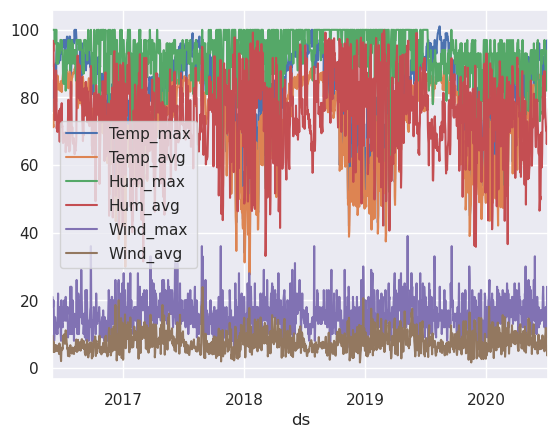

In [32]:
#CODIGO AQUI

#La sensación de frío está determiniada por temperatura, humedad y viento, y el punto de rocío se puede obtener a partir de la humedad y la temperatura, luego tener las tres es redundante, además el mínimo se puede obtener del máximo y el promedio (tener ambos es relevante pues más que la temperatura promedio nos interesa el mayor frío o calor que se pueda haber sentido en el día)
df_exogenas = (
    pd.read_csv("datos_frink.csv")
    .assign( ds=lambda x: pd.to_datetime(x.date))
        )
df_exogenas = df_exogenas.loc[:, ["ds"] + [ 
    variable for variable in list(df_exogenas.columns) if (
        "Temp" in variable 
        or "Hum" in variable 
        or "Wind" in variable 
        ) and "min" not in variable 
    ]
]
display(df_exogenas)
df_exogenas.plot(x="ds",y = df_exogenas.columns.drop(["ds"]))
plt.show()

X_train = (
    X_train
    .merge(df_exogenas, how="left", on="ds")
        )
X_test = (
    X_test
    .merge(df_exogenas, how="left", on="ds")
        )

In [33]:
m = Prophet()
variables_exogenas = df_exogenas.columns.drop("ds")
for variable in variables_exogenas:
    m.add_regressor(variable) 
m.fit(X_train)

22:15:57 - cmdstanpy - INFO - Chain [1] start processing
22:15:57 - cmdstanpy - INFO - Chain [1] done processing


,ds,yhat,yhat_lower,yhat_upper
1488,2020-06-28,32.154234,23.605363,40.578558
1489,2020-06-29,29.766179,21.311428,38.527703
1490,2020-06-30,29.840794,21.597580,38.294378
1491,2020-07-01,30.490682,22.243695,38.407628
1492,2020-07-02,31.452666,23.758110,39.799478
1493,2020-07-03,29.763713,21.453404,38.279129
1494,2020-07-04,32.298942,23.974825,40.531879
1495,2020-07-05,32.914406,24.374931,41.781356
1496,2020-07-06,29.786243,21.593217,38.463494
1497,2020-07-07,29.122702,21.641236,37.611272


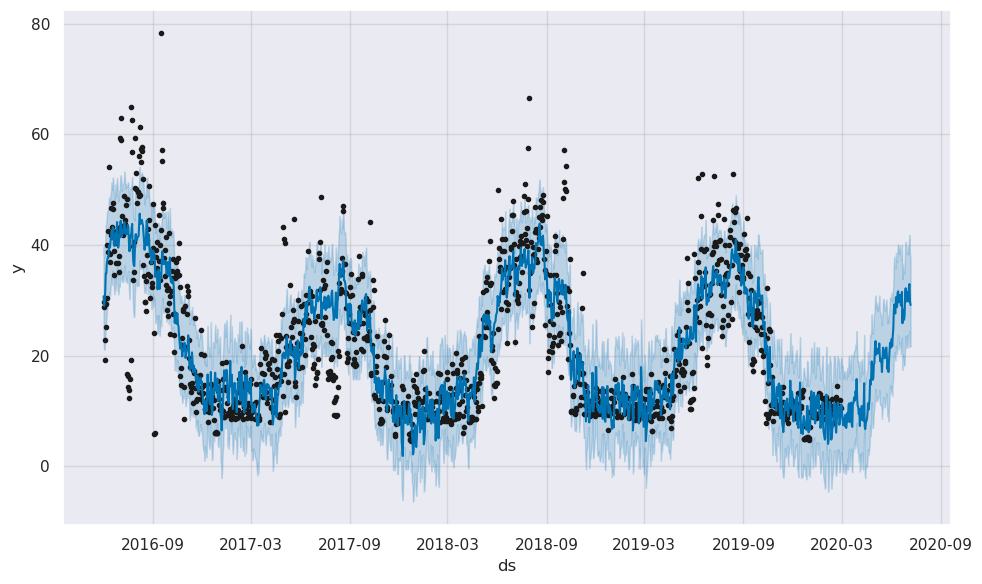

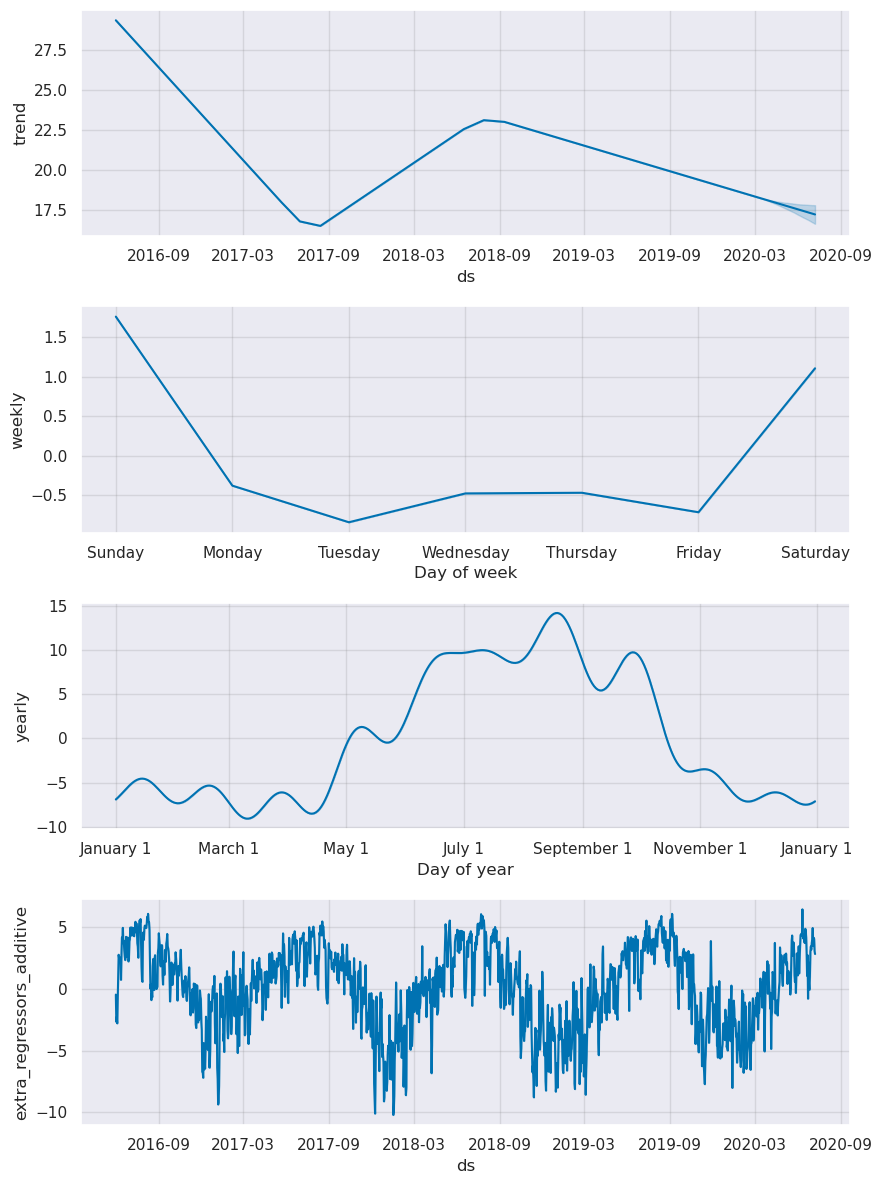

MAE Train: 4.74
MAE Test: 4.59


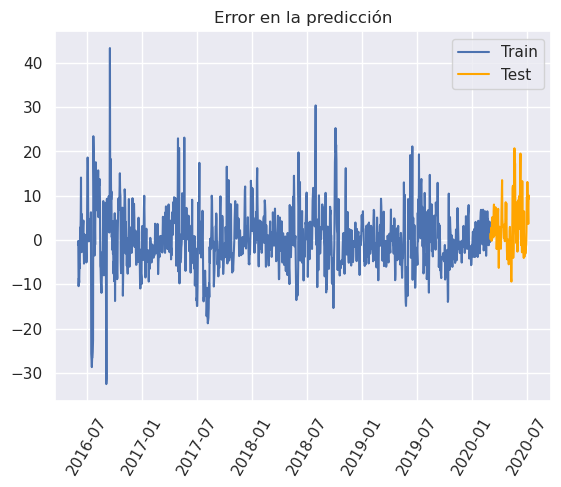

ADF Statistic: -9.72376742557329
p-value: 9.392263102823466e-17


In [34]:
forecast = m.predict(
    pd.concat([
        X_train,
        X_test,
            ])[df_exogenas.columns]
)
prophet_displays(m, forecast)
resultados_prophet_exogenas = Resultados(
    train_pred = forecast.set_index('ds').loc[X_train.ds].yhat,
    test_pred = forecast.set_index('ds').loc[X_test.ds].yhat
 )

resultados_prophet_exogenas.print_maes()
resultados_prophet_exogenas.plot_error()
resultados_trend.test_estacionaridad()

Respecto a estacionalidad el resultado es básicamente el mismo, la serie resultante pasa el test ADF. Además se logra mejorar el resultado de MAE en el conjunto de prueba respecto a la aplicación de prophet sin exógenas, pero aún no se alcanza el resultado obtenido en la primera parte.

## 1.5 Aplicando Lags [7 puntos]

<center>
<img src ="https://i.gifer.com/J45h.gif" width = 400 />

Homero, satisfecho con los resultados obtenidos, cree que aún puede mejorar el rendimiento del modelo incorporando lags de las variables exógenas. Se le ocurre que, al incluir estos lags, podría identificar cómo los valores pasados de las variables influyen en la evolución de la variable objetivo. Con esta idea en mente, Homero solicita su ayuda para encontrar y aplicar los lags adecuados a las variables exógenas de manera efectiva.

Para ello, a usted se le pide que:

1. Calcule la `Autocorrelación Parcial` de las variables exógenas `avg` que usted haya considerado. Por ejemplo: `Temp_avg, Dew_avg, etc`. Luego determine la cantidad de rezagos (lags) que se va a aplicar a cada una de las variables. Justifique. [1 punto]

2. Aplique los lags determinados en el paso anterior e incluyalos como variables en los conjuntos train y test. [1 punto]

3. Impute los valores nulos de los nuevos atributos lags mediante la media de cada variable. [1 punto]

4. Cree y entrene el modelo Prophet e incluya las variables exógenas y adicionalmente sus respectivos lags al modelo. [1 punto]

5. Grafique las predicciones y las componentes del modelo Prophet. `Nota`: Utilice los métodos `.plot()` y `.plot_components()` de Prophet. [1 punto]
6. Calcule el `MAE` de la predicción en el conjunto de prueba y en el de entrenamiento. Analice sus resultados. [1 punto]
7. Grafique el error (Valor real - Valor predicho) en el conjunto de entrenamiento y en el de prueba. ¿Hay un comportamiento estacional en la serie? ¿Como afecta la inclusión de los lags en el desempeño del modelo? [1 punto]


**Respuesta:**

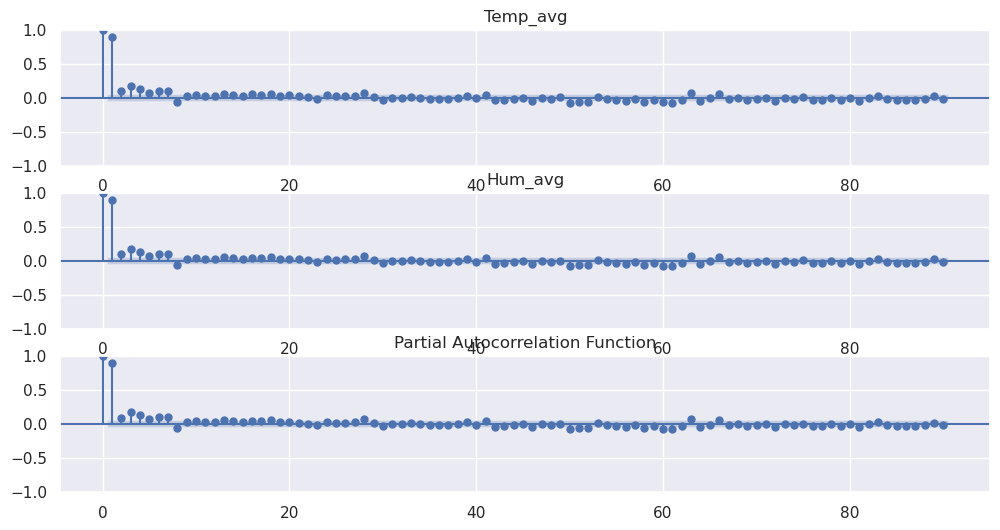

In [35]:
#CODIGO AQUI
from statsmodels.graphics.tsaplots import plot_pacf

#Por indicación de enunciado sólo nos quedamos con las avg
variables_exogenas = [
        variable for variable in list(df_exogenas.columns) if (
            "Temp" in variable 
            or "Hum" in variable 
            or "Wind" in variable 
            ) and "avg" in variable 
        ]

fig, axs = plt.subplots(3, figsize=(12, 6))
for ax, variable in zip(axs, variables_exogenas):
    plot_pacf(y_train, lags=90, alpha = 0.05, ax = ax) # 5% de significancia
    ax.set_title(variable)
plt.title('Partial Autocorrelation Function')
plt.show()

Del gráfico, se observa que la serie temporal muestra una fuerte dependencia al primer rezago $Y_{t-1}$

In [36]:
lag_column_lambdas = {
        f"lag1_{variable}": (lambda frame: frame[variable].shift(1).fillna(frame[variable].mean()))
        for variable in variables_exogenas
    }
X_train = X_train.assign( **lag_column_lambdas)
X_test = X_test.assign( **lag_column_lambdas)

m = Prophet()
variables_exogenas_y_lags = list(X_train.columns.drop(["y","ds"]))
for variable in variables_exogenas_y_lags:
    m.add_regressor(variable) 
m.fit(X_train)

22:16:15 - cmdstanpy - INFO - Chain [1] start processing
22:16:15 - cmdstanpy - INFO - Chain [1] done processing


,ds,yhat,yhat_lower,yhat_upper
1488,2020-06-28,32.130735,23.462495,40.467889
1489,2020-06-29,29.738434,21.188735,38.329579
1490,2020-06-30,29.839397,22.116510,38.136643
1491,2020-07-01,30.483865,21.836967,38.944546
1492,2020-07-02,31.443979,22.785970,39.378804
1493,2020-07-03,29.733686,21.102933,37.301162
1494,2020-07-04,32.283420,24.045475,41.203818
1495,2020-07-05,32.859350,24.073414,41.433499
1496,2020-07-06,29.734723,20.796876,37.967606
1497,2020-07-07,29.087970,20.823947,37.337906


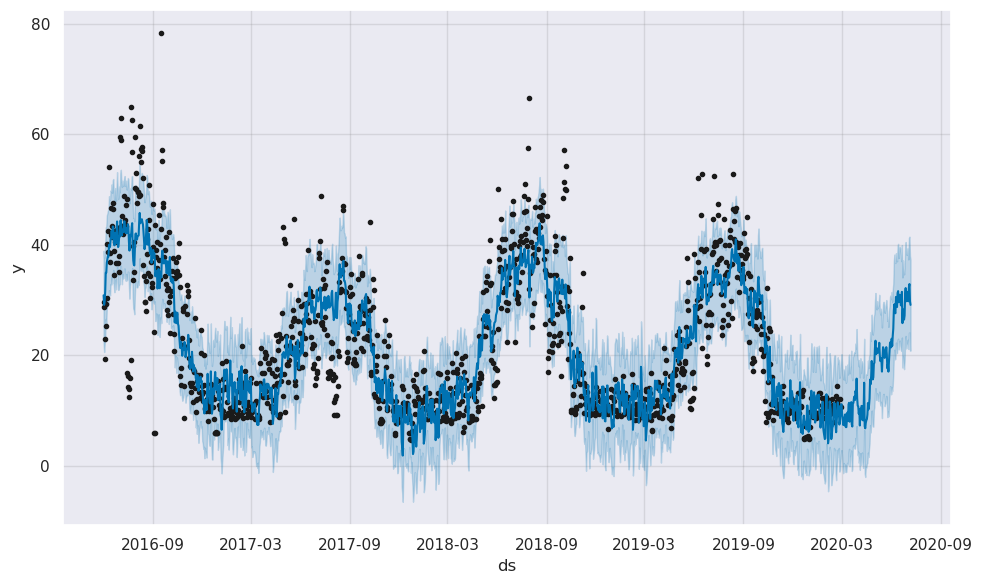

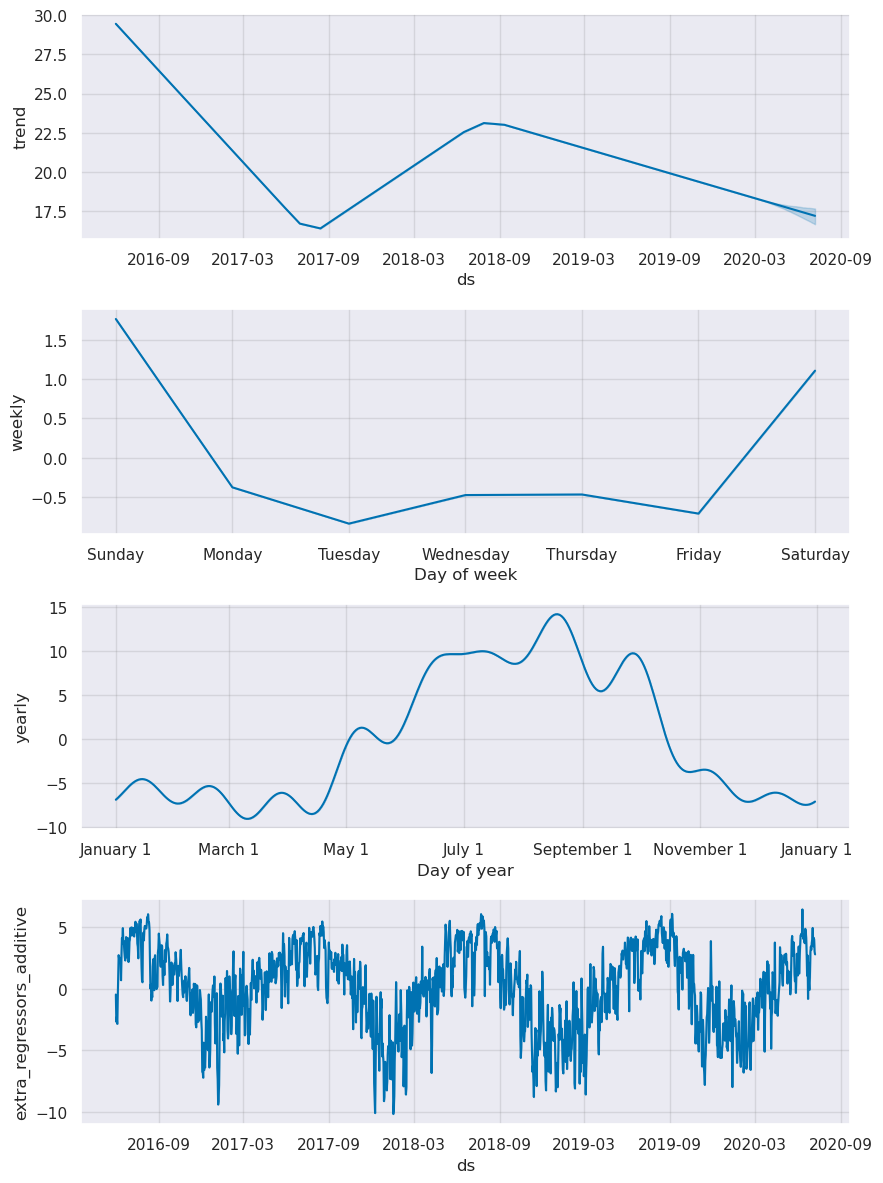

MAE Train: 4.74
MAE Test: 4.60


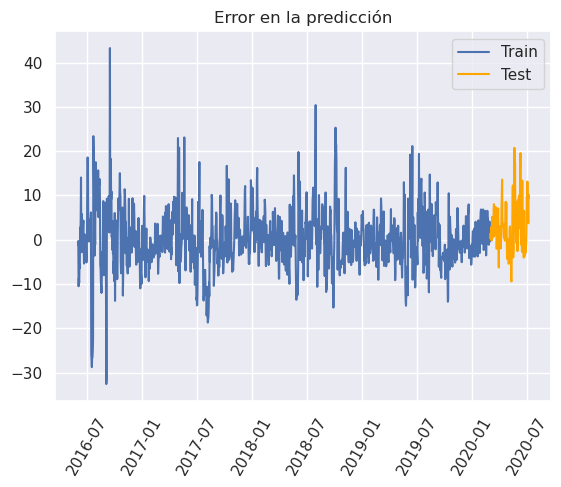

ADF Statistic: -9.72376742557329
p-value: 9.392263102823466e-17


In [38]:
forecast = m.predict(
    pd.concat([
        X_train,
        X_test,
            ])[variables_exogenas_y_lags+["ds"]]
)

prophet_displays(m, forecast)

resultados_AplicandoLags =  Resultados(
    train_pred = forecast.set_index('ds').loc[X_train.ds].yhat,
    test_pred = forecast.set_index('ds').loc[X_test.ds].yhat,
        )
resultados_AplicandoLags.print_maes()
resultados_AplicandoLags.plot_error()
resultados_trend.test_estacionaridad()

La aplicación de lags no logra mejorar los resultados previamente obtenidos.

## 1.6 Optimizando Prophet [6 puntos]

<center>
<img src ="https://i.gifer.com/BKlg.gif" width = 500 />

Homero, contento con sus resultados, decide compartir su trabajo en LinkedIn. Sin embargo, justo antes de realizar la publicación, su hija Lisa Simpson le comenta que su modelo podría mejorar aún más mediante la optimización de hiperparámetros. Aunque Homero no entiende muy bien a qué se refiere Lisa, decide confiar en su conocimiento y le pide ayuda para implementar la optimización.

Lisa le prepara una función llamada optimize_prophet, que recibe como entrada el registro histórico, los datos a predecir (futuros), el nombre de las variables exógenas y una grilla de hiperparámetros que se desea modificar.

Después de varios intentos, Homero no logra utilizar la función de Lisa y, desesperado por publicar sus resultados en internet, se acerca a usted en busca de ayuda.

Para ello, usted decide realizar los siguientes pasos:

1. Crear una grilla donde se modifiquen los siguientes hiperparámetros: `changepoint_prior_scale`, `seasonality_prior_scale`, `seasonality_mode`, `changepoint_range` y encuentre los hiperparámetros que optimicen el `MAE`. `Nota:` Utilice la función `optimize_prophet()` dada en el enunciado. [1 punto]
2. Crear y entrenar un modelo Prophet utilizando los mejores parámetros encontrados, incluyendo regresores (variables exógenas). [2 puntos]
3. Grafique las predicciones y las componentes del modelo Prophet. `Nota`: Utilice los métodos `.plot()` y `.plot_components()` de Prophet. [1 punto]
4. Calcule el `MAE` de la predicción en el conjunto de entrenamiento y en el de prueba. [1 punto]
5. Grafique el error (Valor real - Valor predicho) en ambos conjuntos. Analice sus resultados. [1 punto]


In [39]:
#NO MODIFICAR ESTA CELDA

import itertools
import numpy as np
import pandas as pd
from tqdm import tqdm
import logging...

# Silenciar el logging de Prophet
logging.getLogger('prophet').setLevel(logging.ERROR)
logging.getLogger('cmdstanpy').setLevel(logging.ERROR)


def optimize_prophet(df, df_to_pred, features, param_grid ):
  '''
  Función que recibe como entrada:
  -df: data entrenamiento.
  -df_to_pred: data a predecir (test).
  -features: lista de variables exógenas.
  -param_grid: grilla de hiperparámetros.

  Retorna:
  -tuning_results: Dataframe con resultados de la optimización.
  -best_params: Diccionario de mejores parámetros encontrados.
  '''

  # Generate all combinations of parameters
  all_params = [dict(zip(param_grid.keys(), v)) for v in itertools.product(*param_grid.values())]
  MAEs = []  # Store the MAEs for each params here

  # Use tqdm to add a progress bar to the parameter tuning loop
  for params in tqdm(all_params, desc="Tuning Prophet parameters"):
      m = Prophet(**params)  # Fit model with given params
      for feature in features:
          m.add_regressor(feature)
      m.fit(df)

      # Prepare future dataframe
      df_prop = m.make_future_dataframe(periods=len(df_to_pred))
      df_feat = pd.concat([df[features], df_to_pred[features]]).reset_index(drop=True)
      df_prop[features] = df_feat[features]

      # Make predictions
      forecast = m.predict(df_prop)
      forecast_pred = forecast[forecast['ds'].isin(df_to_pred['ds'])].reset_index(drop=True)

      # Calculate MAE for the predictions
      mae_pred = mean_absolute_error(df_to_pred['y'], forecast_pred['yhat'])
      MAEs.append(mae_pred)

  # Find the best parameters
  tuning_results = pd.DataFrame(all_params)
  tuning_results['MAEs'] = MAEs
  tuning_results = tuning_results.sort_values(by='MAEs', ascending=True)
  best_params = all_params[np.argmin(MAEs)]
  return tuning_results, best_params

**Respuesta:**

In [40]:
#CODIGO AQUI
grilla = { 
    'changepoint_prior_scale':[0.2, 0.5, 0.8],
    'seasonality_prior_scale':[5, 10, 15],
    'seasonality_mode':['additive', 'multiplicative'],
    'changepoint_range':[0.4, 0.6, 0.8]
}
_, best_params = optimize_prophet(X_train, X_test, variables_exogenas_y_lags, grilla )

Tuning Prophet parameters: 100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 54/54 [00:30<00:00,  1.76it/s]


In [41]:
m = Prophet(**best_params)
variables_exogenas_y_lags = list(X_train.columns.drop(["y","ds"]))
for variable in variables_exogenas_y_lags:
    m.add_regressor(variable) 
m.fit(X_train)

,ds,yhat,yhat_lower,yhat_upper
1488,2020-06-28,37.082543,26.803869,47.736995
1489,2020-06-29,34.919951,25.062200,45.452163
1490,2020-06-30,34.977990,24.668969,46.372075
1491,2020-07-01,35.556961,25.016974,46.457435
1492,2020-07-02,36.488551,25.907338,47.268888
1493,2020-07-03,34.380663,23.970066,45.124156
1494,2020-07-04,36.961675,26.975047,47.699262
1495,2020-07-05,37.735625,27.486172,49.012315
1496,2020-07-06,34.894713,23.891880,46.438611
1497,2020-07-07,33.960652,23.503540,44.719052


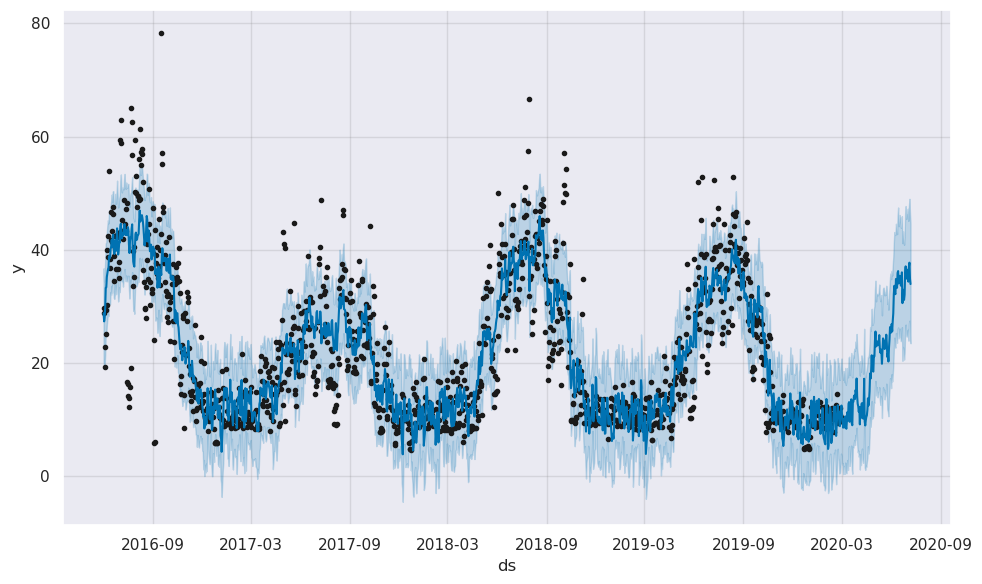

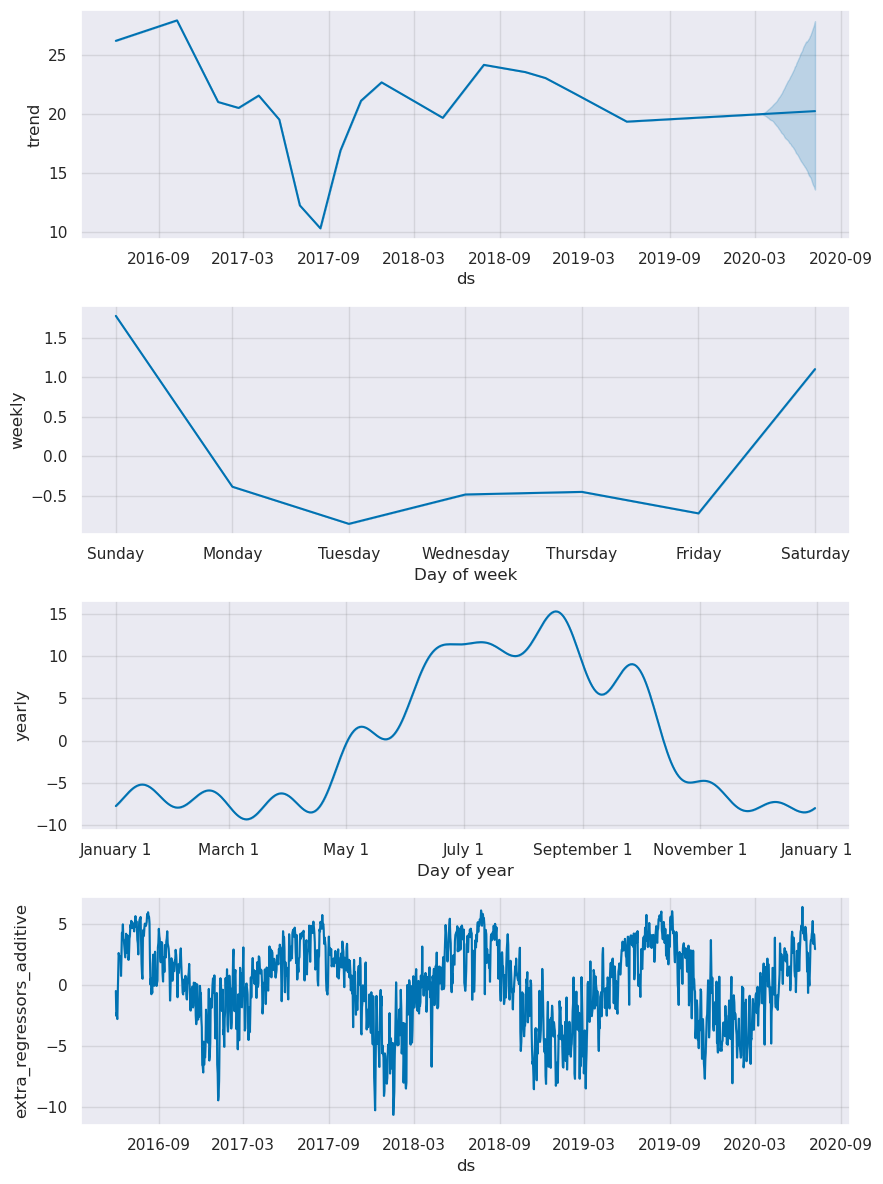

MAE Train: 4.53
MAE Test: 4.14


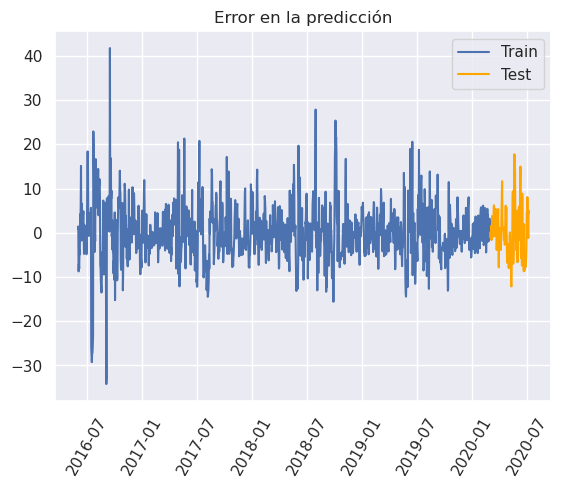

ADF Statistic: -9.72376742557329
p-value: 9.392263102823466e-17


In [42]:
forecast = m.predict(
    pd.concat([
        X_train,
        X_test,
            ])[variables_exogenas_y_lags+["ds"]]
)

prophet_displays(m, forecast)

resultados_optimizando =  Resultados(
    train_pred = forecast.set_index('ds').loc[X_train.ds].yhat,
    test_pred = forecast.set_index('ds').loc[X_test.ds].yhat,
        )
resultados_optimizando.print_maes()
resultados_optimizando.plot_error()
resultados_trend.test_estacionaridad()

Finalmente se logra una mejora apreciable en los resultados y no queda duda de que se elimina la estacionalidad en la serie.

# **2. Sistemas de Recomendación (30 puntos)**

## Homero contra la Prohibición

<center>
<img src ="https://i.ytimg.com/vi/rMSXXuhZjYY/maxresdefault.jpg" width = 500 />

En Springfield, el caos estalló cuando las autoridades prohibieron el alcohol. Pero como siempre, donde otros ven problemas, Homero Simpson ve oportunidades. Decidido a mantener las fiestas vivas, se convirtió en el Barón de la Cerveza en un abrir y cerrar de ojos. Con la ayuda de su buen amigo Moe el cantinero, Homero obtuvo un valioso dataset llamado `cervezas.csv`, que contiene valoraciones de los ciudadanos de Springfield sobre distintas cervezas. Homero quiere asegurarse de ofrecer las cervezas más apreciadas para mantener a su clientela oculta y feliz, mientras eludía la mirada del estricto Elio Pez. Por ende, Homero lo contacta para solicitar de su ayuda en esta nueva labor.

El dataset contiene los siguientes atributos:

  * userId: Identificador de los ciudadanos/usuarios
  * beerId: Identificador único de cada cerveza
  * rating: Evaluación otorgada por el ciudadano a la cerveza, en un rango de 1.0 a 5.0.
  * beerName: Nombre de la cerveza
  * beerStyle: Tipo de Cerveza.



In [25]:
# Librerias extras
from sklearn.preprocessing import LabelEncoder

from surprise import accuracy
from surprise.reader import Reader
from surprise.dataset import Dataset
from surprise.model_selection import train_test_split
from surprise.prediction_algorithms.knns import KNNBasic
from surprise.prediction_algorithms.matrix_factorization import SVD
from surprise.accuracy import mae
from surprise import NMF
from collections import defaultdict
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.metrics.pairwise import cosine_similarity

import pandas as pd
from copy import deepcopy
import matplotlib.pyplot as plt

## Carga de los datos [0 puntos]

Cargue el dataset `cervezas.csv` y realice una breve exploración de los datos. ¿Hay valores nulos? ¿Cuantos cervezas se estan evaluando? ¿Cuantos ciudadanos participaron de esta evaluación?

In [2]:
#CODIGO AQUI
df_cervezas = pd.read_csv("cervezas.csv")
display(df_cervezas)
print(
  "Valores Nulos por variable:\n",
  df_cervezas.isna().sum()
)
print(
  "Cantidad de Cervezas:",
  len(df_cervezas["beerId"].unique())
)
print(
  "Cantidad de Ciudadanos que participaron de la evaluación:",
  len(df_cervezas["userId"].unique())
)

,userId,beerId,rating,beerName,beerStyle
0,144,995,3.0,Mai Bock,Maibock / Helles Bock
1,63,58695,4.0,Hop In The Dark Cascadian Dark Ale,American Black Ale
2,147,4083,5.0,Stone Ruination IPA,American Double / Imperial IPA
3,4261,40310,3.0,Noël Des Géants,Herbed / Spiced Beer
4,140,1904,5.0,Sierra Nevada Celebration Ale,American IPA
...,...,...,...,...,...
295054,863,45653,4.0,Consecration,American Wild Ale
295055,306,1341,4.0,Keystone Light,Light Lager
295056,8,8917,3.0,Drop Top Amber,American Amber / Red Ale
295057,35,102,3.0,Samuel Adams Octoberfest,Märzen / Oktoberfest


Valores Nulos por variable:
 userId       0
beerId       0
rating       0
beerName     0
beerStyle    0
dtype: int64
Cantidad de Cervezas: 3747
Cantidad de Ciudadanos que participaron de la evaluación: 706


## 2.1 Caracterización Inicial [3 puntos]

Antes de entrenar nuestro sistema recomendador, es necesario caracterizar los datos disponibles y de esta manera tener un mejor entendimiento del problema a resolver. Para esto, se le pide lo siguiente:

1. Genere gráficos y/o estadística descriptiva con los datos. Utilice su análisis para responder las siguientes preguntas: [2 puntos]
  - ¿Cuantos *usuarios* hay en los datos?
  - ¿Cuantos *productos* hay en los datos?
  - ¿Cuantas *calificaciones* hay en los datos?
  - ¿Cuantas *calificaciones* faltantes hay en los datos?
  - ¿Cual es la media de las *calificaciones* entregadas por los usuarios? ¿Cómo cambia esto a través de los productos?  
2. Transforme los datos entregados a una matriz (usuario, producto) y muestre sus resultados. [1 punto]

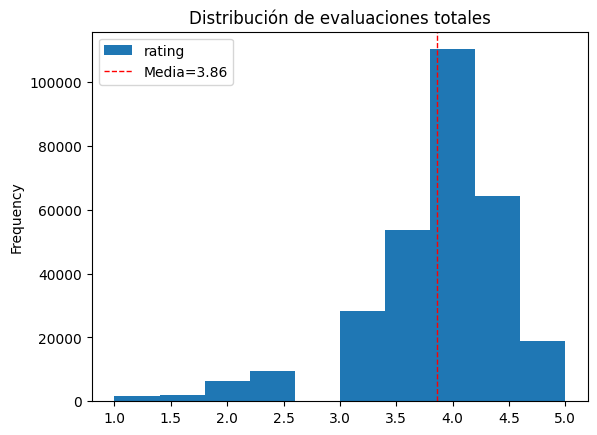

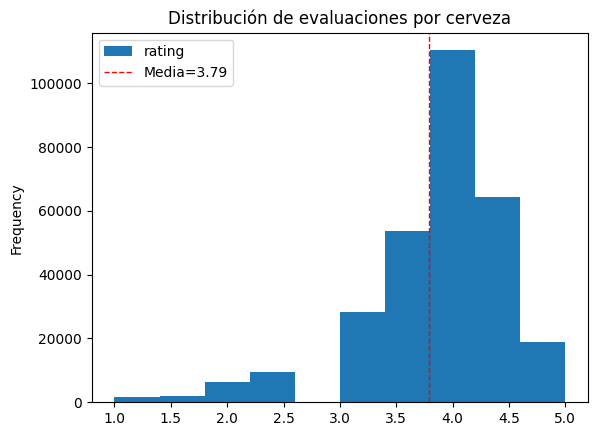


Cervezas más votadas:


,rating_count,rating,beerName,beerStyle
beerId,,,,
56082,59,4.669492,Citra DIPA,American Double / Imperial IPA
1545,310,4.666129,Trappist Westvleteren 12,Quadrupel (Quad)
36316,42,4.654762,Cantillon Blåbær Lambik,Lambic - Fruit
1062,68,4.639706,Live Oak HefeWeizen,Hefeweizen
16814,122,4.639344,Heady Topper,American Double / Imperial IPA
42664,20,4.625000,Kaggen! Stormaktsporter,Russian Imperial Stout
64545,25,4.620000,Double Sunshine IPA,American Double / Imperial IPA
61100,26,4.615385,King Henry,English Barleywine
21690,142,4.605634,Pliny The Younger,American Double / Imperial IPA


Cantidad de productos: 3747
Cantidad de usuarios: 706
Cantidad de calificaciones: 295059
Cantidad de calificaciones faltantes: 2641635


In [8]:
df_cervezas.rating.plot(kind="hist", title="Distribución de evaluaciones totales")
calificacion_media = df_cervezas.rating.mean()
plt.axvline(calificacion_media, color='r', linestyle='dashed', linewidth=1, label=f"Media={round(calificacion_media, 2)}")
plt.legend()
plt.show()

agrupado_por_cervezas = (
    df_cervezas.groupby("beerId").agg({
        "userId": "count",
        "rating": "mean",
        "beerName": "first",
        "beerStyle": "first"
    })
    .rename(columns={"userId": "rating_count"})
    .sort_values(by="rating", ascending=False)
)

df_cervezas.rating.plot(kind="hist", title="Distribución de evaluaciones por cerveza")
calificacion_media = agrupado_por_cervezas.rating.mean()
plt.axvline(calificacion_media, color='r', linestyle='dashed', linewidth=1, label=f"Media={round(calificacion_media, 2)}")
plt.legend()
plt.show()
print("\nCervezas más votadas:")
display(
    agrupado_por_cervezas.head(10)
)
print(
  "Cantidad de productos:",
  len(df_cervezas["beerId"].unique())
)
print(
  "Cantidad de usuarios:",
  len(df_cervezas["userId"].unique())
)
print(
  "Cantidad de calificaciones:",
  len(df_cervezas["rating"])
)

calificaciones_existentes = len(df_cervezas[["userId", "beerId"]].drop_duplicates())
calificaciones_posibles = (
    len(df_cervezas[["userId"]].drop_duplicates())
    *
    len( df_cervezas[[ "beerId"]].drop_duplicates())
            )

print(
  "Cantidad de calificaciones faltantes:",
  calificaciones_posibles - calificaciones_existentes
)


In [53]:
#df_cervezas[["userId", "beerId"]].value_counts()
(
    df_cervezas
    .assign(
        rating_count = lambda x: x.rating,
        rating_mean = lambda x: x.rating,
        rating_std = lambda x: x.rating,
    )
    .groupby(["userId", "beerId"]).aggregate({
    "rating_count": "count",
    "rating_mean": "mean",
    "rating_std": "std",
})
)

rating_count  rating_mean  rating_std
userId beerId                                       
1      429              329     3.834347    0.707585
3      5                100     3.395000    0.753091
       6                230     3.765217    0.641783
       7                146     3.256849    0.763920
       9                 23     3.478261    0.665348
...                     ...          ...         ...
24903  72465             38     4.289474    0.474079
25317  68087             21     3.523810    0.732738
25923  70745             30     4.233333    0.365148
27039  16814            122     4.639344    0.353625
27681  59622             26     3.269231    0.533494

[3747 rows x 3 columns]

Extrañamente cada usuario puntua muchas veces la misma cerveza (a veces cientos!!) por lo que se trabajará con la calificación promedio que cada usuario le da a una cerveza.

In [56]:
(
    df_cervezas[["userId", "beerId","rating"]]
    .groupby(["userId", "beerId"]).mean()
    .reset_index()
    .pivot(
        columns="beerId",
        index="userId",
        values="rating"
    ).fillna(0)

)

beerId,5,6,7,9,10,11,14,15,17,19,...,74491,74530,74548,74579,74634,74827,74904,74986,75013,75086
userId,,,,,,,,,,,,,,,,,,,,,
1,0.000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,3.395,3.765217,3.256849,3.478261,0.000000,0.000000,0.000000,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,0.000,0.000000,0.000000,0.000000,3.791908,0.000000,0.000000,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
5,0.000,0.000000,0.000000,0.000000,0.000000,3.431818,0.000000,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
6,0.000,0.000000,0.000000,0.000000,0.000000,0.000000,3.892157,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
24903,0.000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
25317,0.000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
25923,0.000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


## 2.2 Método Basado en Contenido [4 puntos]

<center>
<img src ="https://is1-ssl.mzstatic.com/image/thumb/WfNa_TwFpJoTWXQmU-BrbA/1200x675.jpg" width = 500 />

Como primera tarea, Homero le pide centrarse en las características de las cervezas y no en la interacción de los ciudadanos con esta. Adicionalmente, Homero le quiere regalar un pack de distintas cervezas a Carl en agradecimiento a su ayuda anterior, el cual se enteró que Carl tiene un `userId = 100`. Por ende, Homero le pide las siguientes acciones:

1. Cree un dataframe que contenga las características de las cervezas, excluyendo las evaluaciones de los ciudadanos. `Nota:` No considere valores duplicados. [1 punto]
2. Implemente el método Bag of Words para procesar la columna `beerStyle`. Para ello, transforme las palabras a minúsculas, elimine stopwords en inglés y filtre las palabras que aparezcan en 10 documentos como mínimo. Guarde su resultado como un DataFrame. [1 punto].
> `Nota:` Le puede ser útil esta [documentacion](https://scikit-learn.org/1.5/modules/generated/sklearn.feature_extraction.text.CountVectorizer.html) y el método `.get_feature_names_out()`.
3. Cree una función que imprima las top 5 cervezas similares a `Chocolate Porter`, utilizando como medida de similitud la similitud coseno. [1 punto]
4. Identifique la cerveza mejor evaluada por Carl (`userId = 100`) y obtenga las top 5 cervezas similares a esa cerveza. [1 punto]

**Respuesta:**

In [12]:
#CODIGO AQUI
df_bow = (
    df_cervezas
    .groupby('beerId')[['beerName', 'beerStyle']].first()
    .reset_index()
)
display(df_bow.head())

vectorizer = CountVectorizer(lowercase = True, # transformación a minúsculas
                             min_df = 10, # mínimo 10 ocurrencias
                             stop_words = 'english') # eliminar stopwords
bow = vectorizer.fit_transform(df_bow['beerStyle']).toarray() # Vectorizamos texto
bow = pd.DataFrame(bow, columns=vectorizer.get_feature_names_out()) # Transformamos a Dataframe
bow


,beerId,beerName,beerStyle
0,5,Amber,Vienna Lager
1,6,Turbodog,English Brown Ale
2,7,Purple Haze,Fruit / Vegetable Beer
3,9,Golden,American Pale Lager
4,10,Allagash Dubbel Ale,Dubbel


,adjunct,ale,altbier,amber,american,apa,baltic,barleywine,beer,belgian,...,vienna,warmer,wee,weizenbock,wheat,wheatwine,wild,winter,witbier,zwickel
0,0,0,0,0,0,0,0,0,0,0,...,1,0,0,0,0,0,0,0,0,0
1,0,1,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,0,0,0,0,0,0,0,0,1,0,...,0,0,0,0,0,0,0,0,0,0
3,0,0,0,0,1,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3742,0,0,0,0,1,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3743,0,1,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3744,0,0,0,0,1,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3745,0,1,0,0,1,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [22]:
# calculamos la similitud coseno de cada vector generado contra el resto
cosine_sim = cosine_similarity(bow, bow)
def get_recommendations(df, beer_name, k = 5):

  """
  Returns the top k similar beers using BoW
  """

  # Assert beer is contained in dataset
  assert beer_name in df['beerName'].values, 'beer is not contained in train dataset!'

  # Get idx of beer
  idx = df[df['beerName'] == beer_name].index[0]

  # Get pairwise similarities of all beers with specified beer
  sim_scores = list(enumerate(cosine_sim[idx]))

  # Sort the beers based on the similarity scores
  sim_scores = sorted(sim_scores, key=lambda x: x[1], reverse=True)

  # Get the scores of the k most similar beers
  sim_scores = sim_scores[1:k+1]

  # Get the beer indices
  beer_indices = [i[0] for i in sim_scores]

  # Return the top k most similar beers
  return df['beerName'].iloc[beer_indices].values

cerveza =  'Chocolate Porter'
print(
    f'5 Cervezas más parecidas a la {cerveza}:',
    *get_recommendations(df = df_bow, beer_name = cerveza),
    sep="\n\t *"

)



5 Cervezas más parecidas a la Chocolate Porter:
	 * Blackhook Porter
	 * Anchor Porter
	 * Coffeehouse Porter
	 * Drayman's Porter
	 * Stone Smoked Porter


In [24]:
# primero rescatamos la cerveza más vista por el usuario
userId = 100 # usuario a recomendar
best_beer = (
    df_cervezas[df_cervezas['userId'] == userId]
    .sort_values('rating', ascending = False)
    .iloc[0]['beerName']
        )
print(f'Cerveza mejor evaluada por Carl (userId = {userId}): {best_beer}')
print(
    f'5 Cervezas más parecidas:',
    *get_recommendations(df = df_bow, beer_name = best_beer),
    sep="\n\t * "

)


Cerveza mejor evaluada por Carl (userId = 100): McNeill's Firehouse Amber Ale
5 Cervezas más parecidas:
	 * Full Sail Amber
	 * McNeill's Firehouse Amber Ale
	 * Grail Ale
	 * American Amber Ale
	 * Ruedrich's Red Seal Ale


## 2.3 Filtros Colaborativos [16 puntos]

<center>
<img src ="https://i.makeagif.com/media/2-08-2016/McmGFQ.gif" width = 400 />

Después de consolidarse como el Barón de la Cerveza en Springfield, Homero Simpson decidió llevar su negocio clandestino a otro nivel. Al ser el único proveedor de alcohol en la ciudad, quiere asegurarse de que cada cerveza que elabora sea de la mejor calidad posible. Para lograrlo, planea usar las evaluaciones pasadas que los ciudadanos de Springfield han registrado sobre las distintas cervezas. Inspirado por los consejos de su amigo Moe, Homero se enteró de que puede implementar un sistema de recomendación basado en filtros colaborativos.

Ahora, Homero necesita de su ayuda para diseñar y elaborar distintos sistemas de filtros colaborativos que le permitan continuar con su reinado cervecero.

### 2.3.1 Filtros Colaborativos Basados en Memoria [8 puntos]

Para este tipo de filtros, Homero le pide lo siguiente:

1. Transforme el DataFrame de `pandas` a Dataset de `surprise`. `Hint`: Utilice solamente los identificadores de ciudadano, cerveza y rating. ¿Importa el orden? [1 punto]
2. Genere un conjunto de entrenamiento y uno de prueba, asegurando que el 30% de los datos sea destinado al conjunto de prueba. No olvide fijar una semilla para garantizar reproducibilidad. [1 punto]
3. Entrene un modelo de **KNN basado en usuarios** utilizando la `similitud coseno`. Luego realice predicciones en el conjunto de prueba. `Nota`: Le puede ser útil la siguiente [documentación](https://surprise.readthedocs.io/en/stable/knn_inspired.html) [2 puntos]
4. Calcule el MAE (Mean Absolute Error) de las predicciones realizadas por el modelo y muestre las predicciones en un DataFrame para su análisis. `Nota:` Le puede ser útil la siguiente [documentación](https://surprise.readthedocs.io/en/stable/accuracy.html#surprise.accuracy.mae) [2 puntos]
5. Repita los pasos 3 y 4 pero utilizando un modelo de **KNN basado en los productos**. [2 puntos]

**Respuesta:**

El orden al crear dataset de surprise es clave, para que la librería identifique usuario, producto y rating y no los confunda.

In [26]:
#CODIGO AQUI
reader = Reader(rating_scale = (0, 5)) # instanciamos reader, es importante definir la escala de los valores (ratings)

df_collaborative = df_cervezas[['userId', 'beerId', 'rating']].copy() # ordenamos dataset en user, beer, rating (paso clave para trabajar con Surprise)
dataset = Dataset.load_from_df(df_collaborative, reader) # generamos Dataset de Surprise
display(dataset)


trainset, testset = train_test_split(data = dataset, test_size = 0.3, random_state = 99)
trainset


In [33]:
sim_options1 = {
        "name": "cosine",
        "user_based": True,
        }
model_KNN1 = KNNBasic(sim_options=sim_options1) # instanciamos modelo KNN (cambiar a modelo de preferencia)
model_KNN1.fit(trainset) # fit del modelo
predictions = model_KNN1.test(testset) # retorna un dataframe con el rating estimado para cada (user_id, item_id)
print("MAE KNN basado en usuarios: ",mae(predictions, verbose=False))


sim_options2 = {
        "name": "cosine",
        "user_based": False,
        }
model_KNN2 = KNNBasic(sim_options=sim_options2) # instanciamos modelo KNN (cambiar a modelo de preferencia)
model_KNN2.fit(trainset) # fit del modelo
predictions = model_KNN2.test(testset) # retorna un dataframe con el rating estimado para cada (user_id, item_id)
print("MAE KNN basado en productos: ",mae(predictions, verbose=False))


Computing the cosine similarity matrix...
Done computing similarity matrix.
MAE KNN basado en usuarios:  0.4644954287355083
Computing the cosine similarity matrix...
Done computing similarity matrix.
MAE KNN basado en productos:  0.46475185869655333


### 2.3.2 Filtros Colaborativos Basados en Modelo [8 puntos]

Ahora Homero le pide que cambie el enfoque del tipo de filtro colaborativo a uno basado en modelo. Por ende, Homero le pide lo siguiente:

1. Entrene un modelo `NMF` , asegurándose de fijar la semilla para reproducibilidad. Luego genere predicciones para el conjunto de prueba. [2 puntos]
2. Calcule el MAE de las predicciones obtenidas y muestre los resultados de las predicciones en un DataFrame para su analisis. [1 punto]
3. Entrene un modelo `SVD` sobre el conjunto de entrenamiento. Posteriormente, genere las predicciones para el conjunto de prueba. [2 puntos]
4. Calcule el MAE de las predicciones y muestre los resultados de las predicciones en un DataFrame. [1 punto]
5. Compare los resultados de ambos modelos y seleccione el mejor a su criterio. Justifique. [2 puntos]

**Respuesta**

In [53]:
#CODIGO AQUI
model_NMF = NMF(random_state = 99) # instanciamos modelo NMF (cambiar a modelo de preferencia)
model_NMF.fit(trainset) # fit del modelo
predictions_NMF = model_NMF.test(testset) # retorna un dataframe con el rating estimado para cada (user_id, item_id)

print("MAE NMF: ",mae(predictions_NMF, verbose=False))

df_predictions = pd.DataFrame(predictions_NMF)
display(df_predictions.drop(columns = ['details']))

model = SVD(random_state = 99) # instanciamos modelo NMF (cambiar a modelo de preferencia)
model.fit(trainset) # fit del modelo
predictions_SVD = model.test(testset) # retorna un dataframe con el rating estimado para cada (user_id, item_id)

print("MAE SVD: ",mae(predictions_SVD, verbose=False))

df_predictions = pd.DataFrame(predictions)
display(df_predictions.drop(columns = ['details']))


MAE NMF:  0.4769400008717107


,uid,iid,r_ui,est
0,96,296,3.5,3.828147
1,184,658,4.0,3.696315
2,10707,63668,4.5,3.646684
3,140,1904,3.0,4.044761
4,703,2434,4.0,3.558688
...,...,...,...,...
88513,3,6,3.5,3.545529
88514,10099,21466,3.0,3.317412
88515,1471,6227,4.0,3.765140
88516,347,3338,5.0,3.964161


MAE SVD:  0.4617449526061193


,uid,iid,r_ui,est
0,96,296,3.5,3.787500
1,184,658,4.0,3.762500
2,10707,63668,4.5,3.687908
3,140,1904,3.0,4.000000
4,703,2434,4.0,3.437500
...,...,...,...,...
88513,3,6,3.5,3.562500
88514,10099,21466,3.0,3.437500
88515,1471,6227,4.0,3.862500
88516,347,3338,5.0,4.362500


De todos los resultados de MAE obtenidos el menor error es el asociado al modelo SVD es por esto que se escoge este modelo como el mejor.

## 2.4 El Mejor Filtro Colaborativo [7 puntos]

<center>
<img src ="https://media.giphy.com/media/citBl9yPwnUOs/giphy.gif" width = 400 />

Homero Simpson desea perfeccionar y extender su sistema de recomendaciones para cervezas en Springfield. En esta fase, busca implementar técnicas que le permitan no solo predecir las preferencias de los ciudadanos, sino también evaluar métricas que midan la eficacia de sus recomendaciones. Con el objetivo de recomendar las mejores K cervezas para usuarios específicos, Homero buscará comprender mejor cómo optimizar su sistema y satisfacer a sus clientes.

Para ello, usted ayudará a Homero realizando las siguientes labores:

1. Implemente la función `get_top_n()` que le permita extraer las `N` mejores cervezas recomendadas para cada ciudadano utilizando las predicciones generadas por el mejor modelo seleccionado en la sección anterior. Luego obtenga las `3` mejores cervezas recomendadas para Carl (`userId = 100`). `Hint`: Para cada ciudadano, elimine las predicciones duplicadas. [2 puntos]
2. Realice predicciones de rating para 5 cervezas aleatorias no evaluadas por Carl, para estimar las calificaciones que Carl podría darles. [1 punto]
3. Calcule los promedios de `precisión@k` y el `recall@k` para `k=10` y `threshold = 3.5`. Analice sus resultados. ¿Es un buen modelo? `Hint:` Utilice la función dada `precision_recall_at_k(...)`. [1 punto]
4. Calcule la `precisión@k` y el `recall@k` para valores de `k` que varíen entre 3 y 25 con paso de 1 unidad. Luego, grafique los resultados y analice el comportamiento de las curvas de precisión y recall en función de `k`. [1 punto]
5. Calcule la `precisión@k` y el `recall@k` para valores de `threshold` que varíen entre 3.0 y 4.5, con paso de 0.1. Luego, grafique los resultados y analice el comportamiento de las curvas de precisión y recall en función de `threshold`. [1 punto]
6. Finalmente utilice el mejor modelo para estimar los ratings faltantes. Muestre sus resultados en una matriz (usuario, producto) sin valores nulos. [1 punto]



In [86]:
#NO MODIFICAR ESTA CELDA
def precision_recall_at_k(predictions, k=10, threshold=3.5):

    user_est_true = defaultdict(list)
    for uid, _, true_r, est, _ in predictions:
        user_est_true[uid].append((est, true_r))
    precisions = dict()
    recalls = dict()
    for uid, user_ratings in user_est_true.items():
        user_ratings.sort(key=lambda x: x[0], reverse=True)
        n_rel = sum((true_r >= threshold) for (_, true_r) in user_ratings)
        n_rec_k = sum((est >= threshold) for (est, _) in user_ratings[:k])
        n_rel_and_rec_k = sum(
            ((true_r >= threshold) and (est >= threshold))
            for (est, true_r) in user_ratings[:k]
        )
        precisions[uid] = n_rel_and_rec_k / n_rec_k if n_rec_k != 0 else 0
        recalls[uid] = n_rel_and_rec_k / n_rel if n_rel != 0 else 0
    return precisions, recalls

**Respuesta:**

In [84]:
#Desarrolle su código aquí

def get_top_n(predictions, n=10):
    """Return the top-N recommendation for each user from a set of predictions.

    Args:
        predictions(list of Prediction objects): The list of predictions, as
            returned by the test method of an algorithm.
        n(int): The number of recommendation to output for each user. Default
            is 10.

    Returns:
    A dict where keys are user (raw) ids and values are lists of tuples:
        [(raw item id, rating estimation), ...] of size n.
    """

    df_predictions = (
        pd.DataFrame(predictions)
        .drop(columns = ['details'])
        .drop_duplicates(subset=['uid', 'iid' ])
            )
    # First map the predictions to each user.
    top_n = defaultdict(list)
    for _, row in df_predictions.iterrows():
        top_n[row.uid].append((row.iid, row.est))

    # Then sort the predictions for each user and retrieve the k highest ones.
    for uid, user_ratings in top_n.items():
        user_ratings.sort(key=lambda x: x[1], reverse=True)
        top_n[uid] = user_ratings[:n]

    return top_n
recomendadas = get_top_n(predictions_NMF, n = 3)[100]

name_mapping = (
    df_cervezas[["beerId", "beerName"]]
    .drop_duplicates()
    .set_index("beerId")
    .beerName
    .to_dict()
        )
print(
    "3 mejores cervezas recomendadas para Carl:",
    *[f"{name_mapping[cerveza]} con rating estimado {round(rating, 2)} " for cerveza, rating in recomendadas],
    sep="\n\t *"
    )



3 mejores cervezas recomendadas para Carl:
	 *McNeill's Extra Special Bitter con rating estimado 3.98 
	 *McNeill's Firehouse Amber Ale con rating estimado 3.93 
	 *McNeill's Pullman's Porter con rating estimado 3.61 


In [85]:
import random

full_trainset = dataset.build_full_trainset() # primero separamos los (usuario, producto) con ratings
missing_ratings = full_trainset.build_anti_testset() # luego obtenemos los valores sin ratings
cinco_predicciones = model_NMF.test(
    random.sample(
      [test_tuple for test_tuple in missing_ratings if test_tuple[0]==100],
      5
      )
    ) # predecimos para los valores faltantes


print(
    "predicciones para 5 cervezas aleatorias no evaluadas para Carl:",
    *[
        f"{name_mapping[cerveza]} con rating estimado {round(rating, 2)} "
        for _, cerveza, _, rating, _ in cinco_predicciones
    ],
    sep="\n\t *"
    )


predicciones para 5 cervezas aleatorias no evaluadas para Carl:
	 *Santa's Private Reserve Ale con rating estimado 2.93 
	 *Blue Point Winter Ale con rating estimado 2.94 
	 *Heineken Premium Light Lager con rating estimado 2.77 
	 *Firestone 11 - Anniversary Ale con rating estimado 3.36 
	 *Squatters IPA con rating estimado 3.2 


In [100]:

k = 10
threshold = 3.5
precisions, recalls = precision_recall_at_k( predictions_NMF, k, threshold)
print(
    f"promedio precisión@k: {np.mean(list(precisions.values()))}\n"
    f"promedio recall@k: {np.mean(list(recalls.values()))}"
)


promedio precisión@k: 0.7328831107513827
promedio recall@k: 0.3246284565690614


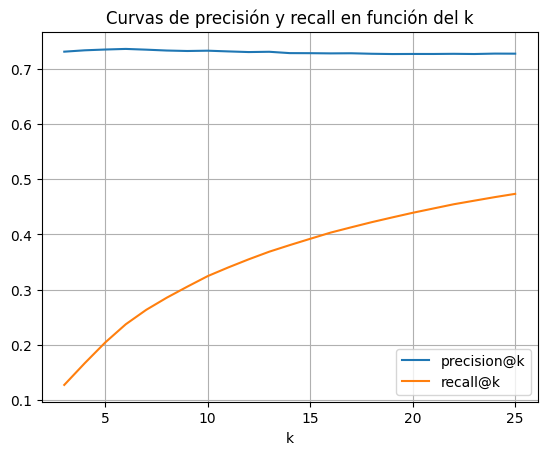

In [105]:
threshold = 3.5
precision_means = []
recall_means = []
for k in range(3,26):
    precisions, recalls = precision_recall_at_k( predictions_NMF, k, threshold)
    precision_means.append(np.mean(list(precisions.values())))
    recall_means.append(np.mean(list(recalls.values())))

plt.plot(range(3, 26), precision_means, label="precision@k")
plt.plot(range(3, 26), recall_means, label="recall@k")
plt.title("Curvas de precisión y recall en función del k")
plt.xlabel("k")
plt.legend()
plt.grid()
plt.show()



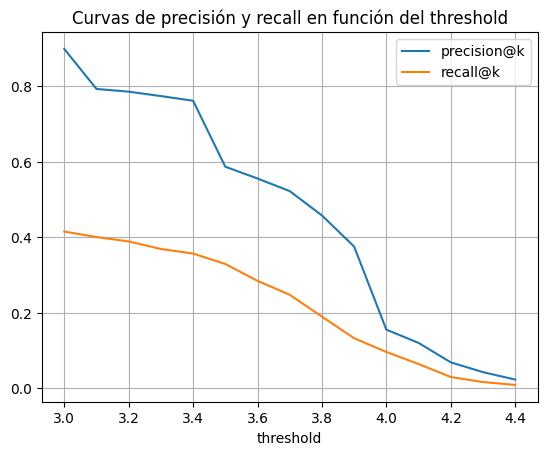

In [109]:
k = 10
precision_means = []
recall_means = []
for threshold in np.arange(3,4.5, 0.1):
    precisions, recalls = precision_recall_at_k( predictions_NMF, k, threshold)
    precision_means.append(np.mean(list(precisions.values())))
    recall_means.append(np.mean(list(recalls.values())))

plt.plot(np.arange(3,4.5, 0.1), precision_means, label="precision@k")
plt.plot(np.arange(3,4.5, 0.1), recall_means, label="recall@k")
plt.title("Curvas de precisión y recall en función del threshold")
plt.xlabel("threshold")
plt.legend()
plt.grid()
plt.show()



In [123]:
faltantes = model_NMF.test(missing_ratings)
df_faltantes = (
        pd.DataFrame(faltantes)
        [["uid", "iid", "est"]]
        .drop_duplicates(subset=['uid', 'iid' ])
        .rename(columns={
          "uid": "userId",
          "iid": "beerId",
          "est": "rating"
        })

            )

In [140]:
pd.concat([
    df_cervezas[["userId", "beerId","rating"]]
    .groupby(["userId", "beerId"]).mean()
    .reset_index(),
    df_faltantes

]).pivot(
        columns="beerId",
        index="userId",
        values="rating"
    )


beerId,5,6,7,9,10,11,14,15,17,19,...,74491,74530,74548,74579,74634,74827,74904,74986,75013,75086
userId,,,,,,,,,,,,,,,,,,,,,
1,2.237102,2.444594,2.319820,1.884690,2.774205,2.820593,2.943736,2.829265,2.087767,2.926696,...,2.872276,2.777649,3.025461,2.887864,2.435051,2.916538,2.794596,3.088361,3.050471,2.754831
3,3.395000,3.765217,3.256849,3.478261,3.065876,2.587830,2.999864,2.835722,2.583678,3.278031,...,2.905513,3.383064,3.219133,3.094757,2.668023,2.641429,3.046766,3.222942,2.554828,3.027580
4,3.172572,3.405215,2.948184,3.047607,3.791908,3.026411,3.429335,2.892284,3.138947,3.382311,...,2.994591,3.755410,3.599803,3.475223,3.231945,3.428588,3.677794,3.533111,3.099809,3.087094
5,2.720488,2.853684,2.696289,2.326027,3.349654,3.431818,2.875290,3.466112,2.934193,3.497932,...,3.087594,3.692396,3.410751,3.358354,3.251466,3.603037,3.395648,3.493787,3.418214,2.783937
6,2.971706,3.108588,2.540009,2.563296,3.297973,2.479087,3.892157,2.387856,2.444751,3.209221,...,2.899157,3.427006,3.555940,3.429377,3.044294,3.180665,3.279920,3.590632,2.811917,2.781037
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
24903,2.955107,3.277839,2.941607,2.880934,3.100122,2.844556,3.023113,3.434506,2.954741,3.657965,...,3.326405,3.563118,3.297503,3.183968,3.025877,3.093887,3.083040,3.644431,3.369163,2.940992
25317,2.397599,2.302666,2.447958,2.120010,2.670563,2.623113,2.213758,2.708409,2.544050,2.550259,...,2.137636,2.250504,2.654911,2.413500,2.712410,2.374085,2.651877,3.075688,2.761656,2.535805
25923,2.569676,2.931836,2.522906,2.463808,3.190061,2.956307,3.016022,2.964843,2.688285,3.247060,...,3.020881,3.942351,3.449251,3.544462,3.005442,3.462186,3.422986,3.342375,3.255391,2.784532


# Conclusión

Éxito!
<center>
<img src ="https://i.gifer.com/origin/cb/cbd80e6045652ab123caffef72f29210_w200.gif" width = 400 />
